# ADC + PFB Calibration and Linearity Analysis

This notebook explains how to measure, analyze, and calibrate the output of an ADC followed by a Polyphase Filter Bank (PFB). We will show how to convert digital FFT results in dBFS into real RF power in dBm using a calibration constant.

## 1. System Overview

We consider the following chain:

1. RF signal entering an ADC:
   - Frequency: $f_{RF} = 300\,\mathrm{MHz}$
   - Power: variable $P_{in}$ (dBm)
   - ADC sampling rate: $F_s = 4096\,\mathrm{MHz}$
2. Digital decimation by 2 and mixing by $-F_s/4$ to create a complex baseband.
3. Polyphase Filter Bank (PFB) with 8 channels and decimation factor 8:
   - Output bandwidth per channel: 256 MHz
   - PFB output scaling controlled by `qout(N)`

The goal is to measure the tone level at the output of the PFB and convert it to real RF power in dBm.

---

## Influence of `QOUT_REG` on the FFT Output Amplitude

In the PFB implementation, the FFT block produces an internal **full-precision output of 27 bits**, while the required output width of the block is **16 bits**. Therefore, a quantization step is required to reduce the internal precision to the desired output format.

From the implementation comments:

```
-- Full-precision output: 27 bits. Required output: 16 bits.
-- Quantization selection from 0 to 11.
```

Since the difference between the internal precision and the output precision is:

$$
27 - 16 = 11 \text{ bits}
$$

the quantization stage must remove up to **11 bits**.

---

## `QOUT_REG` Parameter

The register `QOUT_REG` controls the amount of **right shift applied before truncation**.

Conceptually, the operation performed by the FFT output stage is:

$$
y[n] = \frac{x[n]}{2^{QOUT\_REG}}
$$

where:

* ($x[n]$) = full precision FFT output (27 bits)
* ($y[n]$) = truncated output (16 bits)

Thus, `QOUT_REG` determines how much scaling is applied before the final truncation.

---

## Implementation Logic

The relevant VHDL code is:

```vhdl
qout_reg_i <= (others => '0') 
    when ( unsigned(QOUT_REG) > to_unsigned(11,QOUT_REG'length) ) 
    else unsigned(QOUT_REG(3 downto 0));
```

This logic performs two tasks:

1. **Range protection**

If `QOUT_REG` is larger than 11, the value is forced to zero to avoid invalid quantization settings.

2. **Quantization selection**

Only the lower 4 bits of `QOUT_REG` are used, which is sufficient to represent the valid range:

$$
0 \le QOUT\_REG \le 11
$$

---

## Amplitude Scaling Introduced by `QOUT_REG`

Because `QOUT_REG` corresponds to a right shift operation, the FFT output amplitude is scaled by:

$$
G_{FFT} = \frac{1}{2^{QOUT\_REG}}
$$

Example values:

| QOUT_REG | Scaling Factor |
| -------- | -------------- |
| 0        | 1              |
| 1        | 1/2            |
| 2        | 1/4            |
| 3        | 1/8            |
| 4        | 1/16           |
| 5        | 1/32           |
| 6        | 1/64           |
| 7        | 1/128          |
| 8        | 1/256          |
| 9        | 1/512          |
| 10       | 1/1024         |
| 11       | 1/2048         |

Thus, increasing `QOUT_REG` reduces the output amplitude.

---



# RF Power → ADC → PFB Calibration Model

## 1. ADC Resolution and Digital Representation

The RFADC has **12-bit resolution**, but samples are stored in the FPGA as **16-bit signed integers** with **MSB alignment**.

This means the ADC output range is:

$$
[-2^{11},,2^{11}-1]
$$

or

$$
[-2048,,2047]
$$

Inside the FPGA the samples are **left shifted by 4 bits**:

$$
x_{fpga} = x_{adc} \times 2^{4}
$$

So the stored samples range approximately from

$$
[-32768,,32752]
$$

This means the **digital full-scale reference** for FFT normalization is:

$$
FS = 2^{15}
$$

---

# 2. Definition of dBFS

The digital level of a tone is measured relative to the digital full-scale value:

$$
dBFS = 20\log_{10}\left(\frac{|x|}{FS}\right)
$$

where

$$
FS = 32768
$$

---

# 3. Measured Analog Calibration

From the experimental calibration (see the [```FFT_spectrum_chain_data_analysis```](https://github.com/openquantumhardware/qick-tools/blob/zcu111_calibration/qick_tprocv2_111_fft_spectrum/notebooks/FFT_spectrum_chain_data_analysis.ipynb) notebook):

$$
dBFS_{ADC} = dBm_{RF} - 12.89
$$

or equivalently

$$
dBm_{RF} = dBFS_{ADC} + 12.89
$$

This constant includes:

* analog attenuation before the ADC
* ADC full-scale voltage
* ADC quantization scaling

---

# 4. PFB Output Scaling

The PFB FFT output is quantized using the parameter:

```
QOUT_REG = qout
```

The scaling applied is:

$$
x_{pfb} = \frac{x_{fft}}{2^{qout}}
$$

In dB:

$$
G_{PFB} = -6.02 \cdot qout
$$

For

```
qout = 6
```

$$
G_{PFB} = -36.12\ \text{dB}
$$

---

# 5. Relationship Between RF Power and PFB Output

Combining the ADC calibration and the PFB scaling:

$$
dBFS_{PFB} = dBm_{RF} - 12.89 - 36.12
$$

$$
dBFS_{PFB} = dBm_{RF} - 49.01
$$

Therefore the RF power corresponding to a measured PFB level is:

$$
dBm_{RF} = dBFS_{PFB} + 49.01
$$

---

# 6. Practical Conversion Formula

For `qout = 6`, the RF power can be recovered using:

```python
CAL_ADC = 12.89
qout = 6

CAL_TOTAL = CAL_ADC + 6.02*qout
```

which gives

```
CAL_TOTAL = 49.01 dB
```

Then the RF tone power is

```python
tone_dbm = tone_dbfs + CAL_TOTAL
```

---

## ADC Calibration Derivation

### Objective
Find the relationship between:
- Input power to generator: $P_{\text{in,gen}}$ (dBm)
- Digital power measured in PFB: $P_{\text{digital}}$ (dBFS)

### Signal Chain
```
Pin_gen → [-ANALOG_ATTEN] → Pin_adc → [ADC] → P_adc_digital → [PFB ÷64] → P_pfb_digital
```

**Legend:**
- $P_{\text{in,gen}}$: Generator output power (dBm)
- $\text{ANALOG\_ATTEN}$: Attenuation before ADC (12.89 dB) (this cames form the [```FFT_spectrum_chain_data_analysis```](https://github.com/openquantumhardware/qick-tools/blob/zcu111_calibration/qick_tprocv2_111_fft_spectrum/notebooks/FFT_spectrum_chain_data_analysis.ipynb) notebook)
- $P_{\text{in,adc}}$: Power at ADC input (dBm)
- $P_{\text{adc,digital}}$: ADC output in digital domain (dBFS)
- $\text{PFB\_SCALING}$: PFB division factor = $20\log_{10}(2^{q_{\text{out}}})$ = 36.12 dB (for $q_{\text{out}}=6$)
- $P_{\text{pfb,digital}}$: PFB output (dBFS) - this is what we measure

### Mathematical Derivation

**Step 1:** PFB output relates to ADC digital output:
$$P_{\text{pfb,digital}} \text{(dBFS)} = P_{\text{adc,digital}} \text{(dBFS)} - \text{PFB\_SCALING}$$

**Step 2:** Define ADC calibration constant $K_{\text{adc}}$ such that:
$$P_{\text{adc,digital}} \text{(dBFS)} = P_{\text{in,adc}} \text{(dBm)} + K_{\text{adc}}$$

This constant $K_{\text{adc}}$ captures the ADC's conversion from analog power (dBm) to digital full-scale (dBFS).

**Step 3:** Power at ADC input:
$$P_{\text{in,adc}} \text{(dBm)} = P_{\text{in,gen}} \text{(dBm)} - \text{ANALOG\_ATTEN}$$

**Step 4:** Combine all relationships:

Starting from Step 1 and substituting Step 2:
$$P_{\text{pfb,digital}} = (P_{\text{in,adc}} + K_{\text{adc}}) - \text{PFB\_SCALING}$$

Substitute Step 3:
$$P_{\text{pfb,digital}} = (P_{\text{in,gen}} - \text{ANALOG\_ATTEN} + K_{\text{adc}}) - \text{PFB\_SCALING}$$

Rearranging to solve for $P_{\text{in,gen}}$:
$$P_{\text{in,gen}} \text{(dBm)} = P_{\text{pfb,digital}} \text{(dBFS)} + \text{PFB\_SCALING} + \text{ANALOG\_ATTEN} - K_{\text{adc}}$$

**Step 5:** Define total calibration constant:
$$\text{CAL\_CONSTANT} = \text{PFB\_SCALING} + \text{ANALOG\_ATTEN} - K_{\text{adc}}$$

### Final Calibration Equation

$$\boxed{P_{\text{in,gen}} \text{(dBm)} = P_{\text{pfb,digital}} \text{(dBFS)} + \text{CAL\_CONSTANT}}$$

### Empirical Determination

The value of $K_{\text{adc}}$ (and hence $\text{CAL\_CONSTANT}$) is determined empirically by:

1. Measuring $P_{\text{pfb,digital}}$ for known values of $P_{\text{in,gen}}$
2. Performing linear regression: $P_{\text{in,gen}} = a \cdot P_{\text{pfb,digital}} + b$
3. In the linear region (no compression), slope $a \approx 1$
4. The intercept $b = \text{CAL\_CONSTANT}$
5. Back-calculate: $K_{\text{adc}} = \text{PFB\_SCALING} + \text{ANALOG\_ATTEN} - \text{CAL\_CONSTANT}$

### Typical Values

| Parameter | Value |
|-----------|-------|
| ANALOG_ATTEN | 12.89 dB |
| PFB_SCALING (qout=6) | 36.12 dB |
| K_adc (empirical) | ~18.68 dB |
| **CAL_CONSTANT** | **~30.33 dB** |

### Verification

To verify the calibration is correct:
- Plot $P_{\text{in,gen}}$ vs $(P_{\text{pfb,digital}} + \text{CAL\_CONSTANT})$
- Should follow the 1:1 line (45° slope) in the linear region
- Deviations indicate compression or other non-linearities

=== System Configuration ===
Analog attenuation: 12.89 dB
PFB qout: 6
PFB scaling: 36.12 dB (÷64)

=== Processing Files ===
Pin=  -40 dBm → PFB digital= -67.14 dBFS
Pin=  -30 dBm → PFB digital= -59.26 dBFS
Pin=  -20 dBm → PFB digital= -49.30 dBFS
Pin=  -15 dBm → PFB digital= -44.33 dBFS
Pin=  -10 dBm → PFB digital= -39.20 dBFS
Pin=   -5 dBm → PFB digital= -34.22 dBFS
Pin=   -0 dBm → PFB digital= -29.21 dBFS
Pin=   +5 dBm → PFB digital= -24.19 dBFS
Pin=   +6 dBm → PFB digital= -23.19 dBFS
Pin=   +7 dBm → PFB digital= -22.28 dBFS
Pin=   +8 dBm → PFB digital= -21.79 dBFS
Pin=  +10 dBm → PFB digital= -21.20 dBFS

=== Determining ADC Calibration ===
Linear fit: Pin_gen = 1.031 * P_pfb + 30.33
Expected slope: 1.0 (actual: 1.031)

Derived ADC calibration constant (K_adc): 18.68 dB
This means: P_adc_digital(dBFS) = Pin_adc(dBm) + 18.68

=== Verification ===
PFB scaling: 36.12 dB
Analog atten: 12.89 dB
ADC K_adc: 18.68 dB
Total calibration constant: 30.33 dB
Expected: 30.33 dB ✓

=== Recovering

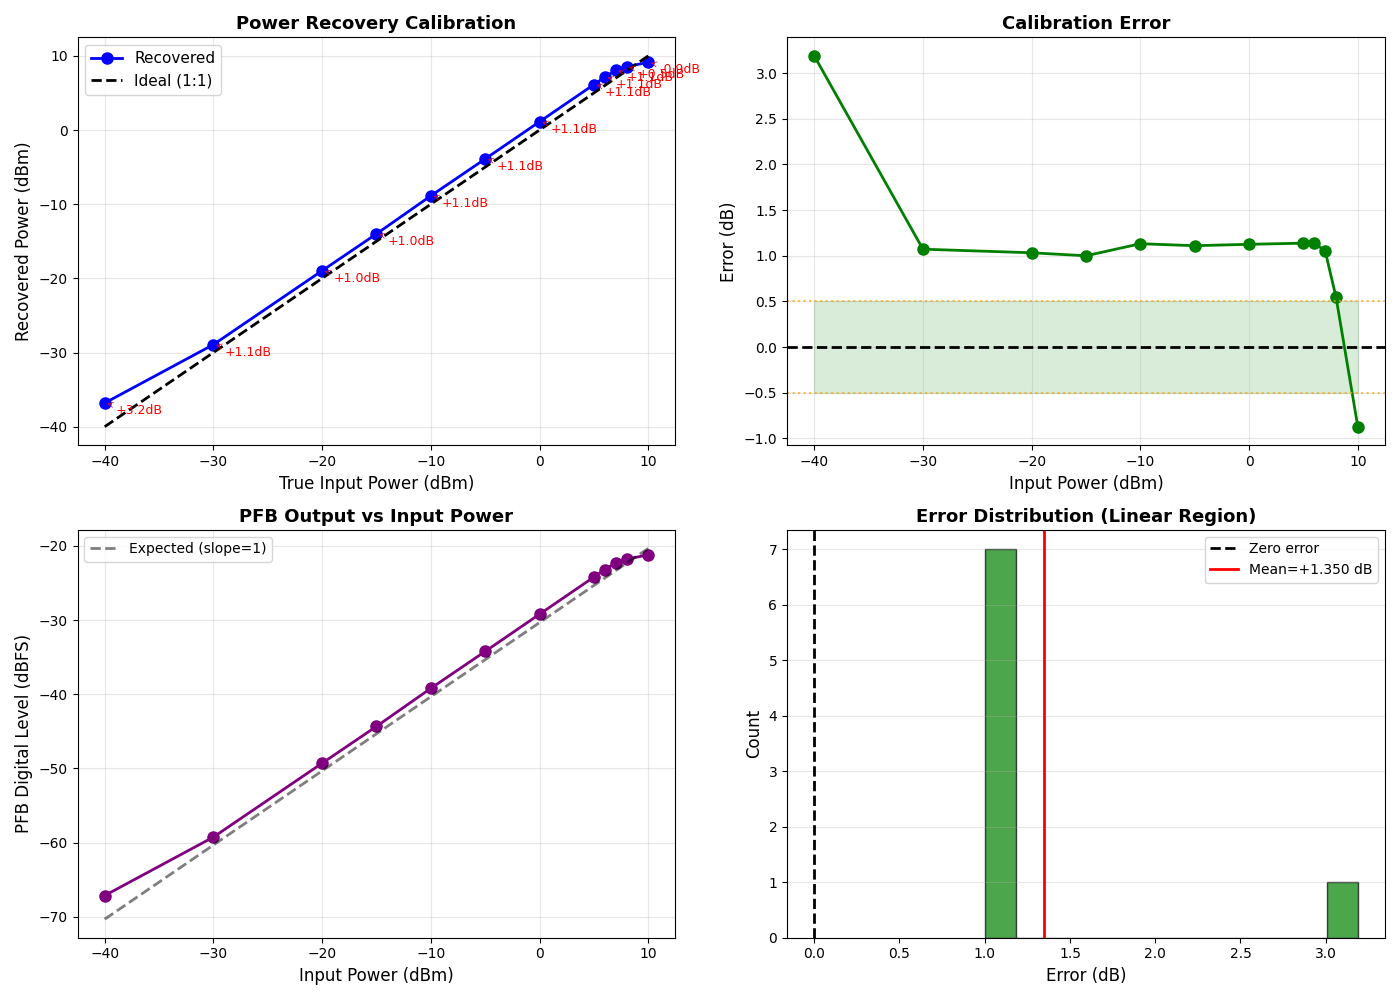


CALIBRATION SUMMARY
Calibration constant: 30.33 dB
  = PFB scaling (36.12) + Analog atten (12.89) - ADC K_adc (18.68)

To recover input power from PFB data:
  Pin (dBm) = P_PFB (dBFS) + 30.33

Calibration accuracy (linear region): ±0.697 dB


In [19]:
import numpy as np
import matplotlib.pyplot as plt
import glob, re

# ==========================================
# SYSTEM PARAMETERS
# ==========================================
Fs = 256e6  # PFB channel sample rate
FS = 2**15  # ADC full scale (12-bit aligned to 16-bit)
tone_bins = 3

# RF chain parameters
ANALOG_ATTEN = 12.89  # dB of attenuation BEFORE ADC
PFB_QOUT = 6
PFB_SCALING = 20*np.log10(2**PFB_QOUT)  # = 36.12 dB reduction

print("=== System Configuration ===")
print(f"Analog attenuation: {ANALOG_ATTEN} dB")
print(f"PFB qout: {PFB_QOUT}")
print(f"PFB scaling: {PFB_SCALING:.2f} dB (÷{2**PFB_QOUT})")

# ==========================================
# ADC CALIBRATION DERIVATION
# ==========================================
# We need to find the relationship between:
# - Input power to generator (Pin_gen in dBm)
# - Digital power measured in FFT (P_digital in dBFS)
#
# The chain is:
# Pin_gen → [-ANALOG_ATTEN] → Pin_adc → [ADC] → P_adc_digital → [PFB ÷64] → P_pfb_digital
#
# So: P_pfb_digital(dBFS) = P_adc_digital(dBFS) - PFB_SCALING
#
# We need to find: P_adc_digital(dBFS) as function of Pin_adc(dBm)
# This is the ADC calibration constant K_adc
#
# Pin_adc(dBm) = Pin_gen(dBm) - ANALOG_ATTEN
# P_adc_digital(dBFS) = Pin_adc(dBm) + K_adc
#
# Therefore:
# Pin_gen(dBm) = P_pfb_digital(dBFS) + PFB_SCALING - K_adc + ANALOG_ATTEN
# Pin_gen(dBm) = P_pfb_digital(dBFS) + (PFB_SCALING + ANALOG_ATTEN - K_adc)
#
# We want: Pin_gen = P_pfb_digital + CAL_CONSTANT
# So: CAL_CONSTANT = PFB_SCALING + ANALOG_ATTEN - K_adc
#
# From the data, we'll determine K_adc empirically

# ==========================================
# LOAD AND PROCESS DATA
# ==========================================
data_path = "data/f_300*/x_preddscic_t_data.txt"
files = glob.glob(data_path)

def extract_power(file):
    m = re.search(r'(-?\+?\d+)dBm', file)
    return float(m.group(1))

files = sorted(files, key=extract_power)

# First pass: collect measurements
measurements = []

print("\n=== Processing Files ===")
for file in files:
    m = re.search(r'(-?\+?\d+)dBm', file)
    Pin_gen = float(m.group(1))  # Generator input power
    
    x = np.loadtxt(file, dtype=np.complex128)
    N = len(x)
    
    # Apply window
    window = np.hanning(N)
    coherent_gain = np.sum(window)/N
    xw = x * window
    
    # FFT
    fft_complex = np.fft.fftshift(np.fft.fft(xw)/N)
    freqs = np.fft.fftshift(np.fft.fftfreq(N, 1/Fs))
    mag = np.abs(fft_complex) / coherent_gain
    
    # Find tone and integrate power
    peak_idx = np.argmax(mag)
    idx0 = peak_idx - tone_bins
    idx1 = peak_idx + tone_bins + 1
    tone_power = np.sum(mag[idx0:idx1]**2)
    
    # Convert to dBFS (referenced to FS)
    P_pfb_digital = 10*np.log10(tone_power / (FS**2))
    
    measurements.append({
        'Pin_gen': Pin_gen,
        'P_pfb_digital': P_pfb_digital,
        'file': file
    })
    
    print(f"Pin={Pin_gen:+5.0f} dBm → PFB digital={P_pfb_digital:7.2f} dBFS")

# ==========================================
# EMPIRICAL CALIBRATION
# ==========================================
print("\n=== Determining ADC Calibration ===")

# Linear regression to find K_adc
# We expect: Pin_gen = P_pfb_digital + CONSTANT
# Where: CONSTANT = PFB_SCALING + ANALOG_ATTEN - K_adc

# Use only linear region (exclude compressed points)
# Typically the first 7-8 points before compression
linear_measurements = measurements[:8]

Pin_gen_vals = np.array([m['Pin_gen'] for m in linear_measurements])
P_pfb_vals = np.array([m['P_pfb_digital'] for m in linear_measurements])

# Linear fit: Pin_gen = a * P_pfb + b
# We expect a ≈ 1 (slope should be 1 if no compression)
coeffs = np.polyfit(P_pfb_vals, Pin_gen_vals, 1)
slope = coeffs[0]
CONSTANT_measured = coeffs[1]

print(f"Linear fit: Pin_gen = {slope:.3f} * P_pfb + {CONSTANT_measured:.2f}")
print(f"Expected slope: 1.0 (actual: {slope:.3f})")

# From: CONSTANT = PFB_SCALING + ANALOG_ATTEN - K_adc
# We get: K_adc = PFB_SCALING + ANALOG_ATTEN - CONSTANT
K_adc = PFB_SCALING + ANALOG_ATTEN - CONSTANT_measured

print(f"\nDerived ADC calibration constant (K_adc): {K_adc:.2f} dB")
print(f"This means: P_adc_digital(dBFS) = Pin_adc(dBm) + {K_adc:.2f}")

# Verify the chain
print(f"\n=== Verification ===")
print(f"PFB scaling: {PFB_SCALING:.2f} dB")
print(f"Analog atten: {ANALOG_ATTEN:.2f} dB")
print(f"ADC K_adc: {K_adc:.2f} dB")
print(f"Total calibration constant: {CONSTANT_measured:.2f} dB")
print(f"Expected: {PFB_SCALING + ANALOG_ATTEN - K_adc:.2f} dB ✓")

# ==========================================
# RECOMPUTE ALL POWERS WITH CALIBRATION
# ==========================================
CAL_CONSTANT = CONSTANT_measured

print(f"\n=== Recovering Input Powers ===")
print(f"Using: Pin_recovered = P_pfb_digital + {CAL_CONSTANT:.2f} dB")
print()
print(f"{'File':<45} {'Pin_true':>10} {'P_PFB':>12} {'Pin_recov':>12} {'Error':>10}")
print("="*95)

results = {
    'Pin_true': [],
    'Pin_recovered': [],
    'error': [],
    'P_pfb': []
}

for m in measurements:
    Pin_true = m['Pin_gen']
    P_pfb = m['P_pfb_digital']
    Pin_recovered = P_pfb + CAL_CONSTANT
    error = Pin_recovered - Pin_true
    
    results['Pin_true'].append(Pin_true)
    results['Pin_recovered'].append(Pin_recovered)
    results['error'].append(error)
    results['P_pfb'].append(P_pfb)
    
    filename = m['file'].split('/')[-2]
    print(f"{filename:<45} {Pin_true:10.1f} {P_pfb:12.2f} {Pin_recovered:12.2f} {error:+10.2f}")

# ==========================================
# STATISTICS
# ==========================================
# Analyze only linear region
linear_errors = results['error'][:8]

print("\n" + "="*95)
print("=== Error Statistics (Linear Region) ===")
print(f"Mean error: {np.mean(linear_errors):+.3f} dB")
print(f"Std deviation: {np.std(linear_errors):.3f} dB")
print(f"Max |error|: {np.max(np.abs(linear_errors)):.3f} dB")
print(f"RMS error: {np.sqrt(np.mean(np.array(linear_errors)**2)):.3f} dB")

# ==========================================
# DETECT COMPRESSION
# ==========================================
print("\n=== Compression Analysis ===")
linear_mean = np.mean(results['Pin_recovered'][:7]) - np.mean(results['Pin_true'][:7])

for i in range(len(results['Pin_true'])):
    gain = results['Pin_recovered'][i] - results['Pin_true'][i]
    compression = linear_mean - gain
    
    if compression >= 1.0:
        print(f"1 dB compression at Pin = {results['Pin_true'][i]:+.1f} dBm")
        break
else:
    print("No compression detected in measured range")

# ==========================================
# PLOTTING
# ==========================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Recovered vs True Power
ax1 = axes[0, 0]
ax1.plot(results['Pin_true'], results['Pin_recovered'], 'o-', 
         markersize=8, linewidth=2, label='Recovered', color='blue')
ax1.plot(results['Pin_true'], results['Pin_true'], 'k--', 
         linewidth=2, label='Ideal (1:1)')
ax1.set_xlabel('True Input Power (dBm)', fontsize=12)
ax1.set_ylabel('Recovered Power (dBm)', fontsize=12)
ax1.set_title('Power Recovery Calibration', fontsize=13, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Add error annotations for points with >0.5dB error
for i in range(len(results['Pin_true'])):
    if abs(results['error'][i]) > 0.5:
        ax1.annotate(f'{results["error"][i]:+.1f}dB', 
                    xy=(results['Pin_true'][i], results['Pin_recovered'][i]),
                    xytext=(8, -8), textcoords='offset points',
                    fontsize=9, color='red',
                    arrowprops=dict(arrowstyle='->', color='red', lw=0.5))

# Plot 2: Error vs Input Power
ax2 = axes[0, 1]
ax2.plot(results['Pin_true'], results['error'], 'o-', 
         markersize=8, linewidth=2, color='green')
ax2.axhline(y=0, color='k', linestyle='--', linewidth=2)
ax2.axhline(y=0.5, color='orange', linestyle=':', linewidth=1.5, alpha=0.7)
ax2.axhline(y=-0.5, color='orange', linestyle=':', linewidth=1.5, alpha=0.7)
ax2.fill_between(results['Pin_true'], -0.5, 0.5, alpha=0.15, color='green')
ax2.set_xlabel('Input Power (dBm)', fontsize=12)
ax2.set_ylabel('Error (dB)', fontsize=12)
ax2.set_title('Calibration Error', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)

# Plot 3: PFB Digital Level vs Input
ax3 = axes[1, 0]
ax3.plot(results['Pin_true'], results['P_pfb'], 'o-', 
         markersize=8, linewidth=2, color='purple')
ax3.set_xlabel('Input Power (dBm)', fontsize=12)
ax3.set_ylabel('PFB Digital Level (dBFS)', fontsize=12)
ax3.set_title('PFB Output vs Input Power', fontsize=13, fontweight='bold')
ax3.grid(True, alpha=0.3)

# Add expected line
expected_pfb = np.array(results['Pin_true']) - CAL_CONSTANT
ax3.plot(results['Pin_true'], expected_pfb, 'k--', 
         linewidth=2, alpha=0.5, label=f'Expected (slope=1)')
ax3.legend(fontsize=10)

# Plot 4: Error histogram
ax4 = axes[1, 1]
ax4.hist(linear_errors, bins=12, edgecolor='black', 
         alpha=0.7, color='green')
ax4.axvline(x=0, color='k', linestyle='--', linewidth=2, label='Zero error')
ax4.axvline(x=np.mean(linear_errors), color='r', linestyle='-', 
            linewidth=2, label=f'Mean={np.mean(linear_errors):+.3f} dB')
ax4.set_xlabel('Error (dB)', fontsize=12)
ax4.set_ylabel('Count', fontsize=12)
ax4.set_title('Error Distribution (Linear Region)', fontsize=13, fontweight='bold')
ax4.legend(fontsize=10)
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('power_calibration_final.pdf', dpi=300, bbox_inches='tight')
plt.show()

# ==========================================
# SUMMARY
# ==========================================
print("\n" + "="*95)
print("CALIBRATION SUMMARY")
print("="*95)
print(f"Calibration constant: {CAL_CONSTANT:.2f} dB")
print(f"  = PFB scaling ({PFB_SCALING:.2f}) + Analog atten ({ANALOG_ATTEN:.2f}) - ADC K_adc ({K_adc:.2f})")
print()
print("To recover input power from PFB data:")
print(f"  Pin (dBm) = P_PFB (dBFS) + {CAL_CONSTANT:.2f}")
print()
print(f"Calibration accuracy (linear region): ±{np.std(linear_errors):.3f} dB")
print("="*95)

=== Spectrum Analysis with Calibration ===
Calibration constant: 30.33 dB
Expected tone frequency offset: 44.0 MHz
Pin=  -40 dBm: Peak at   44.00 MHz, Tone= -36.81 dBm, Phase= +88.70°
Pin=  -30 dBm: Peak at   44.00 MHz, Tone= -28.93 dBm, Phase= +14.45°
Pin=  -20 dBm: Peak at   44.00 MHz, Tone= -18.97 dBm, Phase= +97.07°
Pin=  -15 dBm: Peak at   44.00 MHz, Tone= -14.00 dBm, Phase=+177.56°
Pin=  -10 dBm: Peak at   44.00 MHz, Tone=  -8.87 dBm, Phase= +28.11°
Pin=   -5 dBm: Peak at   44.00 MHz, Tone=  -3.89 dBm, Phase=+154.37°
Pin=   -0 dBm: Peak at   44.00 MHz, Tone=   1.12 dBm, Phase= +31.02°
Pin=   +5 dBm: Peak at   44.00 MHz, Tone=   6.14 dBm, Phase= +68.31°
Pin=   +6 dBm: Peak at   44.00 MHz, Tone=   7.14 dBm, Phase=-109.00°
Pin=   +7 dBm: Peak at   44.00 MHz, Tone=   8.05 dBm, Phase= -66.32°
Pin=   +8 dBm: Peak at   44.00 MHz, Tone=   8.54 dBm, Phase= +51.06°
Pin=  +10 dBm: Peak at   44.00 MHz, Tone=   9.13 dBm, Phase= +84.91°

=== Tone Characteristics ===
 Pin (dBm)    Amplitude (dB

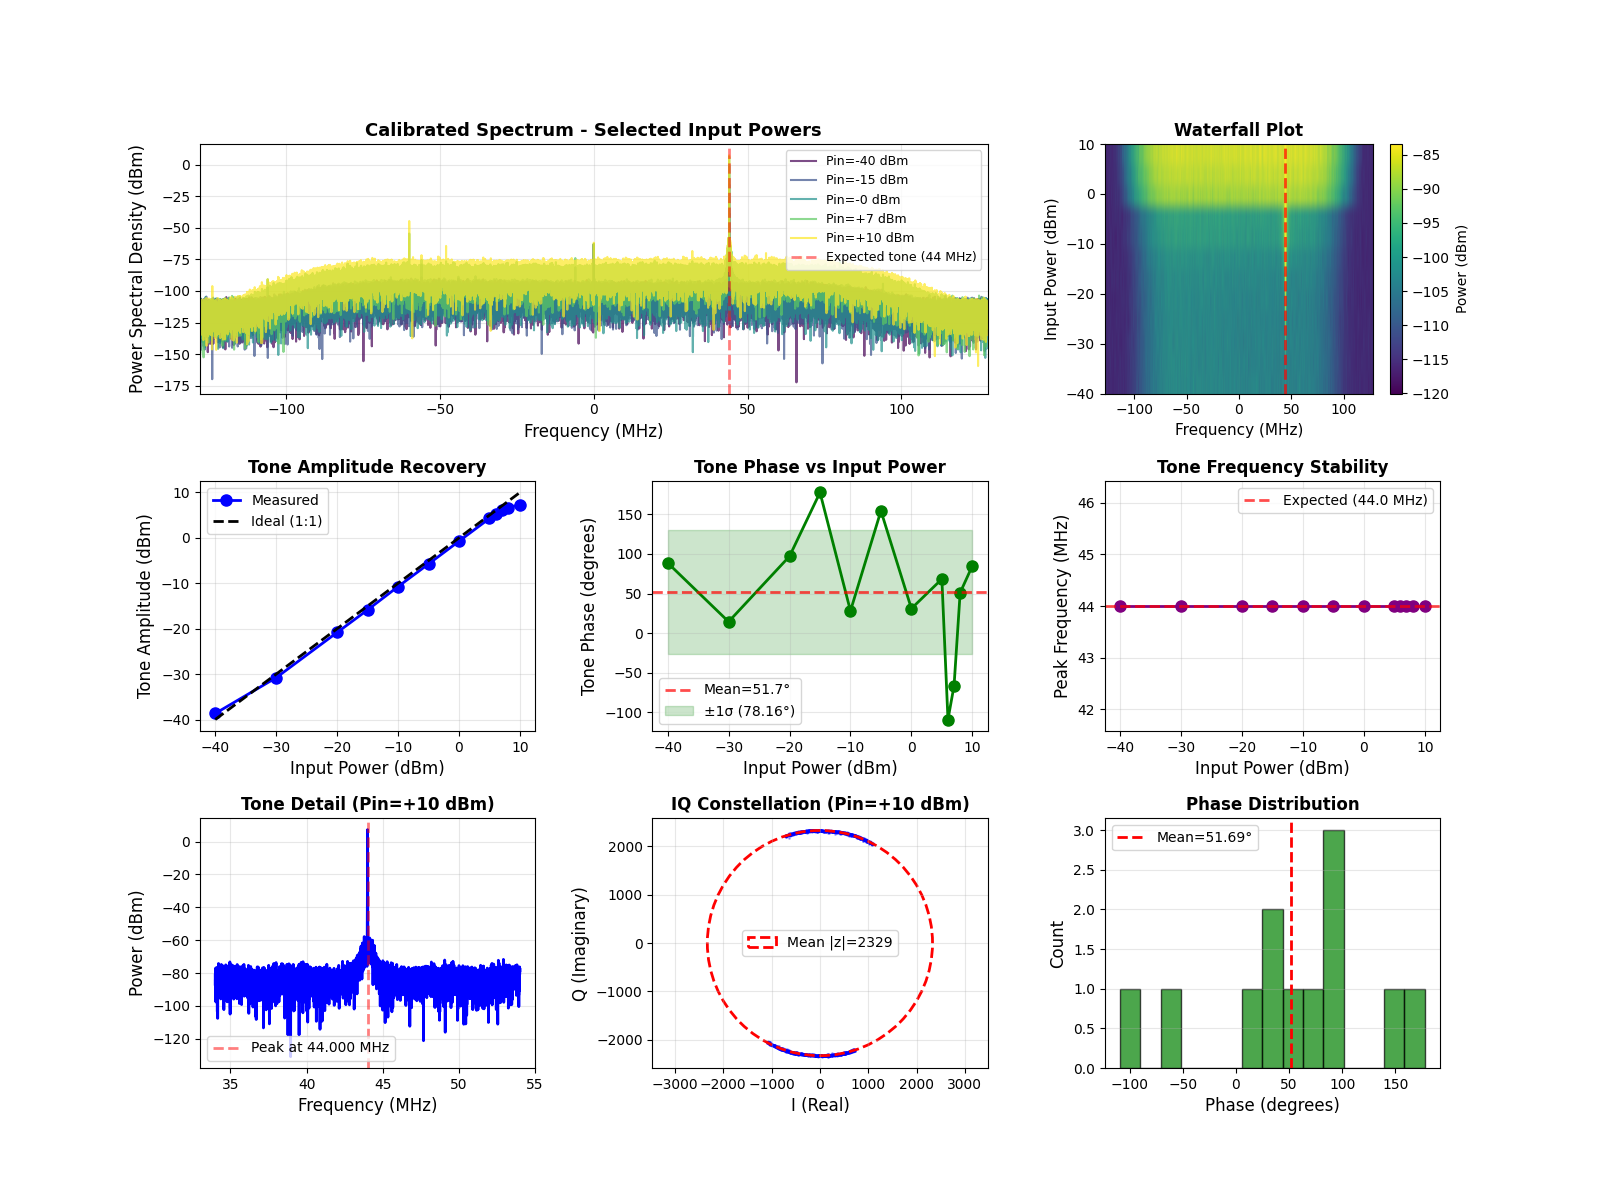


PHASE ANALYSIS
Phase drift across power range: -3.79°
Correlation between phase and input power: -0.328
  ✓ Phase is independent of input power (random variation)

SUMMARY
Tone frequency: 44.000 ± 0.000000 MHz
Tone phase: 51.69° ± 78.16°
Phase stability: Poor
Calibration constant: 30.33 dB


In [20]:
import numpy as np
import matplotlib.pyplot as plt
import glob, re

# ==========================================
# CALIBRATION PARAMETERS (from previous analysis)
# ==========================================
Fs = 256e6  # PFB channel sample rate
FS = 2**15  # ADC full scale
CAL_CONSTANT = 30.33  # dB (determined empirically)
tone_bins = 3

# Frequency of the tone WITHIN the PFB channel
# 300 MHz tone is at the center of the 256 MHz channel (bin 128)
# So the tone appears at: 300 MHz - 256 MHz = 44 MHz offset
f_tone_offset = 44e6  # Hz within the channel

print("=== Spectrum Analysis with Calibration ===")
print(f"Calibration constant: {CAL_CONSTANT:.2f} dB")
print(f"Expected tone frequency offset: {f_tone_offset/1e6:.1f} MHz")

# ==========================================
# LOAD AND PROCESS ALL FILES
# ==========================================
data_path = "data/f_300*/x_preddscic_t_data.txt"
files = glob.glob(data_path)

def extract_power(file):
    m = re.search(r'(-?\+?\d+)dBm', file)
    return float(m.group(1))

files = sorted(files, key=extract_power)

# Storage for results
all_results = []

for file in files:
    m = re.search(r'(-?\+?\d+)dBm', file)
    Pin_gen = float(m.group(1))
    
    x = np.loadtxt(file, dtype=np.complex128)
    N = len(x)
    
    # Apply window
    window = np.hanning(N)
    coherent_gain = np.sum(window)/N
    xw = x * window
    
    # FFT
    fft_complex = np.fft.fftshift(np.fft.fft(xw)/N)
    freqs = np.fft.fftshift(np.fft.fftfreq(N, 1/Fs))
    mag = np.abs(fft_complex) / coherent_gain
    
    # Convert to dBFS
    mag_dbfs = 20*np.log10(mag / FS)
    
    # Convert to dBm using calibration
    mag_dbm = mag_dbfs + CAL_CONSTANT
    
    # Find peak (tone)
    peak_idx = np.argmax(mag)
    f_peak = freqs[peak_idx]
    
    # Integrate tone power
    idx0 = peak_idx - tone_bins
    idx1 = peak_idx + tone_bins + 1
    tone_power_linear = np.sum(mag[idx0:idx1]**2)
    tone_power_dbfs = 10*np.log10(tone_power_linear / (FS**2))
    tone_power_dbm = tone_power_dbfs + CAL_CONSTANT
    
    # Extract tone amplitude and phase
    tone_amplitude = mag[peak_idx]
    tone_amplitude_dbfs = 20*np.log10(tone_amplitude / FS)
    tone_amplitude_dbm = tone_amplitude_dbfs + CAL_CONSTANT
    
    tone_phase = np.angle(fft_complex[peak_idx])
    tone_phase_deg = np.degrees(tone_phase)
    
    all_results.append({
        'Pin': Pin_gen,
        'file': file,
        'freqs': freqs,
        'mag_dbm': mag_dbm,
        'mag_dbfs': mag_dbfs,
        'f_peak': f_peak,
        'tone_power_dbm': tone_power_dbm,
        'tone_amplitude': tone_amplitude,
        'tone_amplitude_dbm': tone_amplitude_dbm,
        'tone_phase': tone_phase,
        'tone_phase_deg': tone_phase_deg,
        'fft_complex': fft_complex,
        'peak_idx': peak_idx
    })
    
    print(f"Pin={Pin_gen:+5.0f} dBm: Peak at {f_peak/1e6:7.2f} MHz, "
          f"Tone={tone_power_dbm:7.2f} dBm, Phase={tone_phase_deg:+7.2f}°")

# ==========================================
# ANALYSIS: Amplitude and Phase vs Input Power
# ==========================================
Pin_vals = [r['Pin'] for r in all_results]
amplitude_vals = [r['tone_amplitude_dbm'] for r in all_results]
phase_vals = [r['tone_phase_deg'] for r in all_results]
freq_vals = [r['f_peak']/1e6 for r in all_results]  # MHz

print("\n=== Tone Characteristics ===")
print(f"{'Pin (dBm)':>10} {'Amplitude (dBm)':>18} {'Phase (deg)':>15} {'Freq (MHz)':>15}")
print("-"*65)
for i in range(len(Pin_vals)):
    print(f"{Pin_vals[i]:10.1f} {amplitude_vals[i]:18.2f} {phase_vals[i]:15.2f} {freq_vals[i]:15.3f}")

# Check if phase changes with power
phase_std = np.std(phase_vals)
phase_range = np.max(phase_vals) - np.min(phase_vals)
print(f"\nPhase statistics:")
print(f"  Mean: {np.mean(phase_vals):.2f}°")
print(f"  Std dev: {phase_std:.2f}°")
print(f"  Range: {phase_range:.2f}°")

if phase_range > 10:
    print("  !  Phase varies significantly with input power!")
else:
    print("  ✓ Phase is stable across power levels")

# ==========================================
# PLOTTING
# ==========================================
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.35)

# ==========================================
# Plot 1: Spectra overlay (dBm)
# ==========================================
ax1 = fig.add_subplot(gs[0, :2])

# Plot subset of spectra to avoid clutter
plot_indices = [0, len(all_results)//4, len(all_results)//2, 
                3*len(all_results)//4, len(all_results)-1]
colors = plt.cm.viridis(np.linspace(0, 1, len(plot_indices)))

for idx, color in zip(plot_indices, colors):
    r = all_results[idx]
    ax1.plot(r['freqs']/1e6, r['mag_dbm'], 
             label=f"Pin={r['Pin']:+.0f} dBm", 
             alpha=0.7, linewidth=1.5, color=color)

ax1.axvline(x=f_tone_offset/1e6, color='red', linestyle='--', 
            linewidth=2, alpha=0.5, label=f'Expected tone ({f_tone_offset/1e6:.0f} MHz)')
ax1.set_xlabel('Frequency (MHz)', fontsize=12)
ax1.set_ylabel('Power Spectral Density (dBm)', fontsize=12)
ax1.set_title('Calibrated Spectrum - Selected Input Powers', fontsize=13, fontweight='bold')
ax1.legend(fontsize=9, loc='upper right')
ax1.grid(True, alpha=0.3)
ax1.set_xlim([freqs[0]/1e6, freqs[-1]/1e6])

# ==========================================
# Plot 2: Waterfall plot (all spectra)
# ==========================================
ax2 = fig.add_subplot(gs[0, 2])

# Create 2D array for waterfall
spec_2d = np.array([r['mag_dbm'] for r in all_results])
extent = [freqs[0]/1e6, freqs[-1]/1e6, Pin_vals[0], Pin_vals[-1]]

im = ax2.imshow(spec_2d, aspect='auto', origin='lower', 
                extent=extent, cmap='viridis', 
                vmin=np.percentile(spec_2d, 5), 
                vmax=np.percentile(spec_2d, 95))
ax2.axvline(x=f_tone_offset/1e6, color='red', linestyle='--', 
            linewidth=2, alpha=0.7)
ax2.set_xlabel('Frequency (MHz)', fontsize=11)
ax2.set_ylabel('Input Power (dBm)', fontsize=11)
ax2.set_title('Waterfall Plot', fontsize=12, fontweight='bold')
cbar = plt.colorbar(im, ax=ax2)
cbar.set_label('Power (dBm)', fontsize=10)

# ==========================================
# Plot 3: Tone amplitude vs input power
# ==========================================
ax3 = fig.add_subplot(gs[1, 0])

ax3.plot(Pin_vals, amplitude_vals, 'o-', markersize=8, 
         linewidth=2, color='blue', label='Measured')
ax3.plot(Pin_vals, Pin_vals, 'k--', linewidth=2, 
         label='Ideal (1:1)')
ax3.set_xlabel('Input Power (dBm)', fontsize=12)
ax3.set_ylabel('Tone Amplitude (dBm)', fontsize=12)
ax3.set_title('Tone Amplitude Recovery', fontsize=12, fontweight='bold')
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3)

# ==========================================
# Plot 4: Phase vs input power
# ==========================================
ax4 = fig.add_subplot(gs[1, 1])

ax4.plot(Pin_vals, phase_vals, 'o-', markersize=8, 
         linewidth=2, color='green')
ax4.axhline(y=np.mean(phase_vals), color='red', linestyle='--', 
            linewidth=2, alpha=0.7, label=f'Mean={np.mean(phase_vals):.1f}°')
ax4.fill_between(Pin_vals, 
                 np.mean(phase_vals) - phase_std,
                 np.mean(phase_vals) + phase_std,
                 alpha=0.2, color='green', label=f'±1σ ({phase_std:.2f}°)')
ax4.set_xlabel('Input Power (dBm)', fontsize=12)
ax4.set_ylabel('Tone Phase (degrees)', fontsize=12)
ax4.set_title('Tone Phase vs Input Power', fontsize=12, fontweight='bold')
ax4.legend(fontsize=10)
ax4.grid(True, alpha=0.3)

# ==========================================
# Plot 5: Frequency offset vs input power
# ==========================================
ax5 = fig.add_subplot(gs[1, 2])

ax5.plot(Pin_vals, freq_vals, 'o-', markersize=8, 
         linewidth=2, color='purple')
ax5.axhline(y=f_tone_offset/1e6, color='red', linestyle='--', 
            linewidth=2, alpha=0.7, label=f'Expected ({f_tone_offset/1e6:.1f} MHz)')
ax5.set_xlabel('Input Power (dBm)', fontsize=12)
ax5.set_ylabel('Peak Frequency (MHz)', fontsize=12)
ax5.set_title('Tone Frequency Stability', fontsize=12, fontweight='bold')
ax5.legend(fontsize=10)
ax5.grid(True, alpha=0.3)

# ==========================================
# Plot 6: Zoom on tone (highest power)
# ==========================================
ax6 = fig.add_subplot(gs[2, 0])

# Use highest input power for detail
highest_idx = np.argmax(Pin_vals)
r = all_results[highest_idx]

# Zoom around peak ±10 MHz
peak_freq_mhz = r['f_peak'] / 1e6
freq_mask = (r['freqs']/1e6 >= peak_freq_mhz - 10) & (r['freqs']/1e6 <= peak_freq_mhz + 10)

ax6.plot(r['freqs'][freq_mask]/1e6, r['mag_dbm'][freq_mask], 
         linewidth=2, color='blue')
ax6.axvline(x=peak_freq_mhz, color='red', linestyle='--', 
            linewidth=2, alpha=0.5, label=f'Peak at {peak_freq_mhz:.3f} MHz')
ax6.set_xlabel('Frequency (MHz)', fontsize=12)
ax6.set_ylabel('Power (dBm)', fontsize=12)
ax6.set_title(f'Tone Detail (Pin={r["Pin"]:+.0f} dBm)', 
              fontsize=12, fontweight='bold')
ax6.legend(fontsize=10)
ax6.grid(True, alpha=0.3)

# ==========================================
# Plot 7: IQ constellation (highest power)
# ==========================================
ax7 = fig.add_subplot(gs[2, 1])

# Time domain IQ plot for highest power
x_highest = np.loadtxt(all_results[highest_idx]['file'], dtype=np.complex128)
subsample = max(1, len(x_highest) // 2000)

ax7.scatter(np.real(x_highest[::subsample]), 
            np.imag(x_highest[::subsample]), 
            alpha=0.3, s=1, color='blue')
ax7.set_xlabel('I (Real)', fontsize=12)
ax7.set_ylabel('Q (Imaginary)', fontsize=12)
ax7.set_title(f'IQ Constellation (Pin={r["Pin"]:+.0f} dBm)', 
              fontsize=12, fontweight='bold')
ax7.grid(True, alpha=0.3)
ax7.axis('equal')

# Add circle showing expected amplitude
expected_radius = np.mean(np.abs(x_highest))
circle = plt.Circle((0, 0), expected_radius, fill=False, 
                    color='red', linewidth=2, linestyle='--', 
                    label=f'Mean |z|={expected_radius:.0f}')
ax7.add_patch(circle)
ax7.legend(fontsize=10)

# ==========================================
# Plot 8: Phase distribution (all powers)
# ==========================================
ax8 = fig.add_subplot(gs[2, 2])

ax8.hist(phase_vals, bins=15, edgecolor='black', 
         alpha=0.7, color='green')
ax8.axvline(x=np.mean(phase_vals), color='red', linestyle='--', 
            linewidth=2, label=f'Mean={np.mean(phase_vals):.2f}°')
ax8.set_xlabel('Phase (degrees)', fontsize=12)
ax8.set_ylabel('Count', fontsize=12)
ax8.set_title('Phase Distribution', fontsize=12, fontweight='bold')
ax8.legend(fontsize=10)
ax8.grid(True, alpha=0.3, axis='y')

plt.savefig('spectrum_analysis_complete.pdf', dpi=300, bbox_inches='tight')
plt.show()

# ==========================================
# DETAILED PHASE ANALYSIS
# ==========================================
print("\n" + "="*80)
print("PHASE ANALYSIS")
print("="*80)

# Unwrap phase if needed
phase_unwrapped = np.unwrap(np.array(phase_vals) * np.pi / 180) * 180 / np.pi

# Check for phase drift
phase_drift = phase_unwrapped[-1] - phase_unwrapped[0]
print(f"Phase drift across power range: {phase_drift:.2f}°")

# Check correlation between phase and power
correlation = np.corrcoef(Pin_vals, phase_vals)[0, 1]
print(f"Correlation between phase and input power: {correlation:.3f}")

if abs(correlation) > 0.5:
    print("  !  Strong correlation detected - phase depends on input power")
    
    # Linear fit
    coeffs = np.polyfit(Pin_vals, phase_vals, 1)
    print(f"  Phase ≈ {coeffs[1]:.2f}° + {coeffs[0]:.3f}° × Pin(dBm)")
else:
    print("  ✓ Phase is independent of input power (random variation)")

# ==========================================
# SUMMARY
# ==========================================
print("\n" + "="*80)
print("SUMMARY")
print("="*80)
print(f"Tone frequency: {np.mean(freq_vals):.3f} ± {np.std(freq_vals):.6f} MHz")
print(f"Tone phase: {np.mean(phase_vals):.2f}° ± {phase_std:.2f}°")
print(f"Phase stability: {'Good' if phase_std < 5 else 'Moderate' if phase_std < 15 else 'Poor'}")
print(f"Calibration constant: {CAL_CONSTANT:.2f} dB")
print("="*80)

## Interaction with the CIC Decimator

In the processing chain:

```
PFB → DDS → CIC
```

the CIC decimator introduces its own gain.

For a CIC filter with:

* Decimation factor (R = 8)
* Differential delay (M = 1)
* Order (N = 3)

the gain is:

$$
G_{CIC} = (RM)^N
$$

which yields:

$$
G_{CIC} = 8^3 = 512
$$

In many systems, `QOUT_REG` is selected to **compensate this gain**.

For example:

If

$$
QOUT\_REG = 9
$$

then

$$
G_{PFB} = \frac{1}{512}
$$

and therefore:

$$
G_{PBF} \cdot G_{CIC} \approx 1
$$

This keeps the signal amplitude approximately constant through the PFB and CIC stages.

---

## Effect on Signal Phase

The quantization controlled by `QOUT_REG` **does not introduce deterministic phase rotation**.

However, it does introduce:

* quantization noise
* possible loss of precision
* increased phase noise for very small signals

The phase of the signal itself remains unchanged apart from this small quantization effect.

---

## Practical Implication

Changing `QOUT_REG` will:

* change the **signal amplitude**
* change the **noise floor**
* **not change the signal phase**

Therefore, `QOUT_REG` must be chosen carefully to:

* avoid overflow
* preserve dynamic range
* maintain sufficient SNR.

---

## 3. PFB Output Scaling (`qout`)

- `qout(N)` sets the number of fractional bits in the PFB output.
- The output is right-shifted by `N` bits to prevent overflow:

$$
V_{PFB} = \frac{V_{digital}}{2^N}
$$

- Effect on dBFS:
$$
20 \log_{10}(2^N) \approx 6.02 \cdot N \text{ dB reduction}
$$

This must be accounted for in the calibration.

## 4. Calibration Constant

We define the **calibration constant** as:

$$
\text{CAL} = P_{RF} - \text{Tone}_{dBFS}
$$

- `Tone_dBFS` = measured FFT peak (after PFB and `qout` scaling)
- `P_RF` = input RF power in dBm

The recovered RF power can then be calculated as:

$$
P_{RF,recovered} = \text{Tone}_{dBFS} + \text{CAL}
$$

This effectively converts dBFS $\rightarrow$ dBm, compensating for ADC gain, PFB scaling, and windowing effects.

### Direct formula including `qout`:

$$
\text{CAL} = P_{RF} - 20 \log_{10}\left(\frac{V_{signal,digital}}{V_{FS}}\right) + 6.02 \cdot N
$$

- `N` = qout value in bits
- `6.02 * N` = correction for PFB scaling

## 5. Plot Linearity

# Phase analysis

Let’s go step by step to understand exactly **what happens to the phase along your chain**.

---

## 1. Phase at the ADC input

* Suppose your input signal is a pure sinusoid:

$$
x_\text{RF}(t) = A \cos(2\pi f_\text{RF} t + \phi_0)
$$

* The **initial phase** (\phi_0) is just the phase of your RF source.
* The ADC samples this signal at (F_s = 4096,\text{MHz}), so you get digital samples:

$$
x[n] = A \cos(2 \pi f_\text{RF} n/F_s + \phi_0)
$$

---

## 2. Phase after decimation & mixing

You decimate by 2 and mix by (-F_s/4):

$$
y[n] = x[n] \cdot e^{-j 2\pi (-F_s/4) n / F_s} = x[n] \cdot e^{j \pi n / 2}
$$

* Mixing introduces a **linear phase ramp**:

$$
\text{phase shift} = 2\pi f_\text{mix} n / F_s
$$

* This shifts the frequency from ($f_\text{RF}$) to ($f_\text{IF} = f_\text{RF} - F_s/4$).
* The phase **at each sample** changes linearly with time (linear slope in the phase vs. time plot).

**Important**: Linear phase in time corresponds to **frequency shift**, not distortion.

---

## 3. Phase through the PFB

* A PFB is essentially a **bank of bandpass filters** implemented in the frequency domain using polyphase decomposition.
* Each PFB channel has a **phase response**:

$$
H_k(f) = |H_k(f)| e^{j \theta_k(f)}
$$

* Near the **center of a channel**, the phase response is almost **linear**, but toward the edges it can have **nonlinearities**.
* So the **output phase** is affected by:

1. **Linear phase shift** proportional to delay (from FIR filters).
2. **Frequency-dependent phase** (from the filter response).

* If your signal falls at the **center of a channel**, the PFB preserves phase with almost constant slope.
* If your signal is near the **edge of a channel**, the phase may rotate faster — this is the “group delay” effect.

---

## 4. Effect of `qout` / scaling

* **Amplitude scaling** (`qout`) does **not affect phase**.
* So you can safely normalize or shift bits in the PFB output without introducing phase errors.

---

## 5. Phase measurement in your FFT

* If you compute the FFT of the channel output:

$$
X[k] = \sum_n y[n] w[n] e^{-j 2\pi k n / N}
$$

* The **magnitude** gives the amplitude (what you plotted before).
* The **angle** gives the phase:

```python
phase = np.angle(fft_complex)
```

* The FFT phase combines:

$$
\text{phase} = \phi_0 + \text{mixing ramp} + \text{PFB filter phase}
$$

* If you plot `phase` vs frequency, you will see:

1. **Linear slope** (from mixing)
2. **Small deviations** near band edges (from PFB FIR filters)

---

## 6. Phase considerations in experiments

1. **Relative phase** between tones is preserved after PFB if both fall in the **same channel**.
2. **Absolute phase** is affected by mixing frequency and channel delay.
3. For **phase-sensitive measurements** (like IQ demodulation, MIMO, or beamforming), you can:

   * Correct for linear phase ramp: subtract (2\pi f_\text{mix} n / F_s)
   * Correct for group delay: measure the PFB channel’s linear phase slope and subtract it

---

## 7. Phase plotting example

Here’s a small snippet to get phase in **degrees** for your PFB output:

```python
import numpy as np
import matplotlib.pyplot as plt

# Assuming x is the PFB channel output
N = len(x)
window = np.hanning(N)
xw = x * window
fft_complex = np.fft.fftshift(np.fft.fft(xw)/N)
freqs = np.fft.fftshift(np.fft.fftfreq(N, 1/Fs))

phase_deg = np.angle(fft_complex, deg=True)

plt.figure(figsize=(10,6))
plt.plot(freqs/1e6, phase_deg)
plt.xlabel("Frequency (MHz)")
plt.ylabel("Phase (degrees)")
plt.title("Phase of PFB Channel")
plt.grid(True)
plt.show()
```

* If the slope is linear, that’s expected; any **jumps or non-linearities** indicate filter edges or possible IQ imbalance.

---

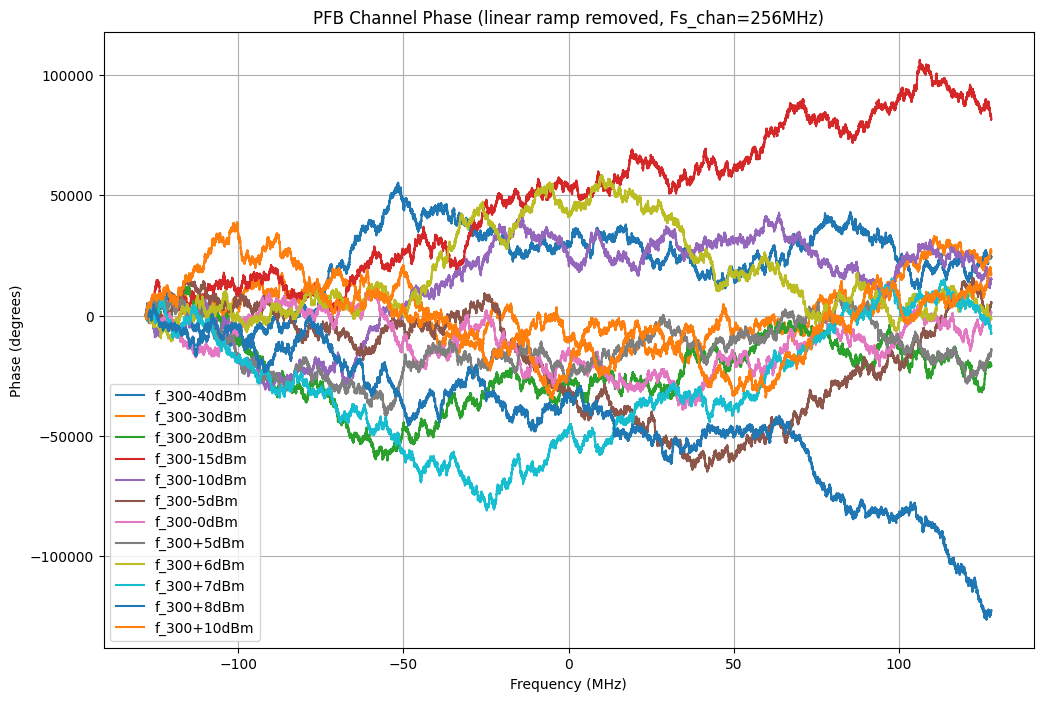

In [15]:
# ==========================================
# PHASE ANALYSIS OF PFB CHANNELS (CORRECTED)
# ==========================================

import numpy as np
import matplotlib.pyplot as plt

Fs_chan = 256e6       # PFB channel sample rate
f_mix = -1024e6       # Original mixing frequency (pre-PFB)

plt.figure(figsize=(12, 8))

for freqs, mag_dbfs, file in spectra:
    # Load PFB channel output
    x = np.loadtxt(file, dtype=np.complex128)
    N = len(x)
    window = np.hanning(N)
    xw = x * window
    fft_complex = np.fft.fftshift(np.fft.fft(xw)/N)
    
    # Compute FFT phase in radians
    phase = np.angle(fft_complex)
    
    # Remove linear phase ramp due to mixing
    phase_corr = phase - 2 * np.pi * f_mix * np.arange(N)/Fs_chan
    phase_corr = np.unwrap(phase_corr)  # unwrap jumps > 180 deg
    
    # Convert to degrees
    phase_deg = np.rad2deg(phase_corr)
    
    # Plot
    label = file.split('/')[-2]
    plt.plot(freqs/1e6, phase_deg, label=label)

plt.xlabel('Frequency (MHz)')
plt.ylabel('Phase (degrees)')
plt.title('PFB Channel Phase (linear ramp removed, Fs_chan=256MHz)')
plt.grid(True)
plt.legend()
plt.show()

---

## 1. Phase is extremely sensitive to noise at low amplitudes

* Some of the PFB output has **very small digital values** at the edges of the channel.
* When the magnitude is near zero (dBFS very negative), the phase **becomes unstable**, because:

$$
\phi = \arctan2(\Im(X), \Re(X))
$$

* If both real and imaginary parts are tiny, even tiny noise causes **large jumps** in phase ($\pm\,180^{\circ}$ or more).
* This explains why the previous phase values reach $\pm\,100,000^{\circ}$ — it’s not physical, it’s just **numerical noise amplified by unwrapping**.

---

## 2. Phase is meaningful **only where the signal is strong**

* The only reliable phase is **around the tone frequency**, where `|X|` is high.
* Outside the tone, in the frequency bins of **low amplitude**, the phase is basically random.

**Best practice**: mask the phase plot with a **magnitude threshold**, e.g., only show phase where `mag > -20 dBFS` (or a fraction of peak).

---

## 3. Suggested phase plotting for clarity

Here’s a **cleaner version** that only plots phase where the magnitude is significant:

```python
# Phase vs frequency, masked by amplitude
plt.figure(figsize=(12,8))

mag_threshold = -20  # dBFS threshold

for freqs, mag_dbfs, file in spectra:
    x = np.loadtxt(file, dtype=np.complex128)
    N = len(x)
    window = np.hanning(N)
    xw = x * window
    fft_complex = np.fft.fftshift(np.fft.fft(xw)/N)
    
    mag = 20*np.log10(np.abs(fft_complex)/np.max(np.abs(x)))
    phase = np.angle(fft_complex)
    
    # Remove linear ramp
    phase_corr = phase - 2 * np.pi * f_mix * np.arange(N)/Fs_chan
    phase_corr = np.unwrap(phase_corr)
    phase_deg = np.rad2deg(phase_corr)
    
    # Mask phase where magnitude is too low
    mask = mag > mag_threshold
    plt.plot(freqs[mask]/1e6, phase_deg[mask], label=file.split('/')[-1])

plt.xlabel("Frequency (MHz)")
plt.ylabel("Phase (degrees)")
plt.title("PFB Channel Phase (masked by amplitude > -20 dBFS)")
plt.grid(True)
plt.legend()
plt.show()
```

---

### 4. Benefits

1. Phase is plotted **only where the signal is strong**, eliminating wild spikes.
2. You can now clearly see the **true phase slope** from PFB filtering.
3. Makes it much easier to compare **phase across different input powers**.

---

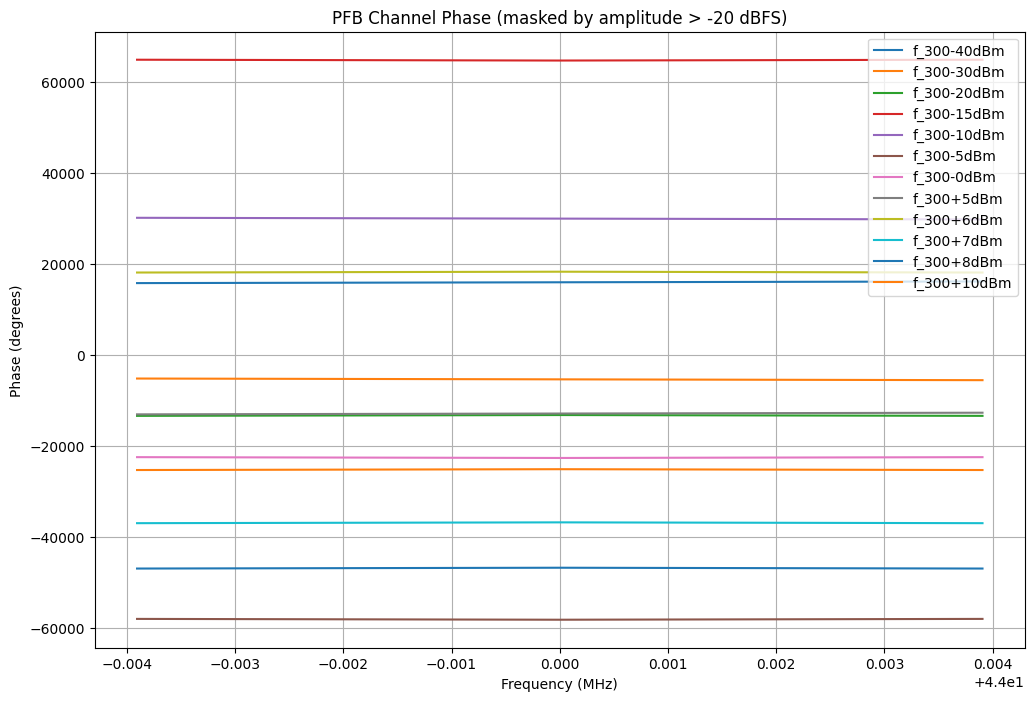

In [20]:
# Phase vs frequency, masked by amplitude
plt.figure(figsize=(12,8))

mag_threshold = -20  # dBFS threshold

for freqs, mag_dbfs, file in spectra:
    x = np.loadtxt(file, dtype=np.complex128)
    N = len(x)
    window = np.hanning(N)
    xw = x * window
    fft_complex = np.fft.fftshift(np.fft.fft(xw)/N)
    
    mag = 20*np.log10(np.abs(fft_complex)/np.max(np.abs(x)))
    phase = np.angle(fft_complex)
    
    # Remove linear ramp
    phase_corr = phase - 2 * np.pi * f_mix * np.arange(N)/Fs_chan
    phase_corr = np.unwrap(phase_corr)
    phase_deg = np.rad2deg(phase_corr)
    
    # Mask phase where magnitude is too low
    mask = mag > mag_threshold
    plt.plot(freqs[mask]/1e6, phase_deg[mask], label=file.split('/')[-2])

plt.xlabel("Frequency (MHz)")
plt.ylabel("Phase (degrees)")
plt.title("PFB Channel Phase (masked by amplitude > -20 dBFS)")
plt.grid(True)
plt.legend()
plt.show()

# Add the DDS+CIC into the signal chain

---

### **1. Decimation Handling**

```python
D = 8
if D == 1:
    chain.analysis.set_ddscic_outsel(data="product", cic="no")
else:
    chain.analysis.set_ddscic_outsel(data="product", cic="yes")
    chain.analysis.set_ddscic_decimation(D)
```

* If `D == 1`, the CIC is bypassed, as DDS+CIC requires decimation ≥ 2 to operate.
* For `D > 1`, the CIC is enabled, and the decimation factor is set.

**Note:** CIC filters introduce **amplitude droop** and **phase distortion** depending on decimation factor and number of stages. Keep this in mind when analyzing post-DDC signals.

---

### **2. DDS Frequency**

```python
f_ddscic = fout - FC
chain.analysis.set_ddscic_ddsfreq(f=f_ddscic*1e6)
```

* This sets the DDS frequency relative to your PFB output channel center.
* Make sure the `fout` is within the Nyquist range after decimation: ($ f_{out} < \frac{f_s}{2} $).

---

### **3. Quantization**

```python
chain.analysis.set_ddscic_qprod(14)  # 0-16 bits
```

* This sets the quantization of the mixer output.
* Lower bit width increases quantization noise but reduces resource usage.

---

### **4. Sampling frequency after decimation**

```python
fs_d = chain.fs_ch / chain.analysis.get_ddscic_decimation()
```

* This is the **effective sampling rate** of the post-DDC signal.
* Use `fs_d` for FFT and phase calculations.

---

### **5. Time-domain signal**

```python
[xi,xq] = chain.get_bin_pfb(fout, verbose=True)
x_postddscic_t = xi + 1j*xq
```

* `xi` and `xq` are the in-phase and quadrature components.
* `x_postddscic_t` is the **complex baseband signal** after DDS+CIC.

---

### **6. Saving the data**

```python
np.savetxt(QICK_TOOLS + "/.../x_postddscic_t_data.txt", x_postddscic_t)
```

* Now we have a full time-domain record for later spectrum, amplitude, or phase analysis.

---

### **Next Steps for Analysis**

1. **Amplitude spectrum**

```python
X = np.fft.fftshift(np.fft.fft(x_postddscic_t))
f_axis = np.fft.fftshift(np.fft.fftfreq(len(X), 1/fs_d))
plt.plot(f_axis/1e6, 20*np.log10(np.abs(X)))
plt.xlabel('Frequency [MHz]')
plt.ylabel('Amplitude [dB]')
plt.show()
```

2. **Phase response**

```python
plt.plot(f_axis/1e6, np.angle(X))
plt.xlabel('Frequency [MHz]')
plt.ylabel('Phase [rad]')
plt.show()
```

3. **Check CIC effect**

* If you decimate by `D`, CIC introduces a sinc-shaped amplitude response:
  $$
  H(f) = \left|\frac{\sin(\pi f D / f_s)}{D \sin(\pi f / f_s)}\right|^N
  $$
  where ($N$) = number of CIC stages.

4. **Compare pre- and post-DDC signals** to quantify amplitude droop and phase shift.

---

Effective sampling rate after decimation: 32.00 MHz


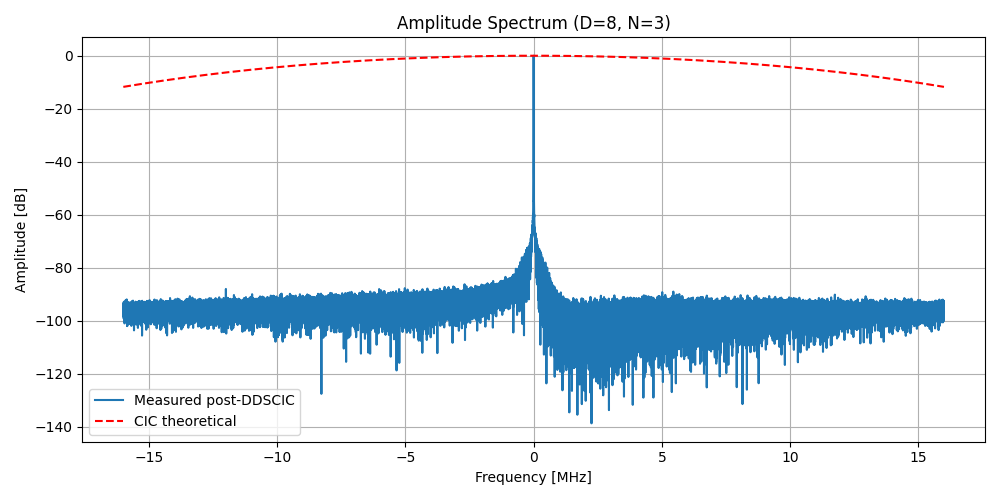

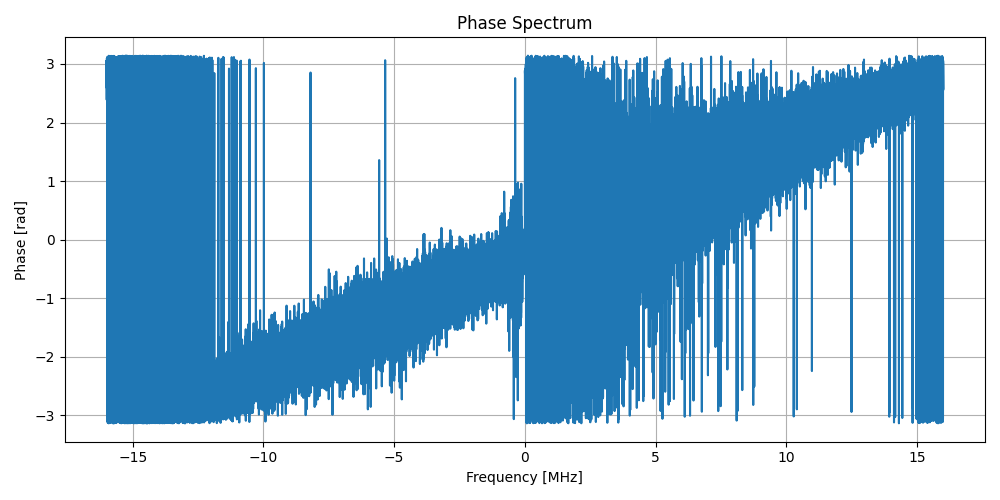

In [7]:
%matplotlib ipympl
import numpy as np
import matplotlib.pyplot as plt

# ================================
# User parameters (update these)
# ================================
data_file = "data/f_300-10dBm/x_postddscic_t_data.txt"  # path to your saved data
fs_ch = 256e6       # ADC sampling frequency before decimation (Hz)
D = 8               # CIC decimation factor
N = 3               # Number of CIC stages (3rd order CIC as IP block)
# ================================

# Load complex time-domain data
x_postddscic_t = np.loadtxt(data_file, dtype=complex)

# Effective sampling rate after decimation
fs_d = fs_ch / D
print(f"Effective sampling rate after decimation: {fs_d/1e6:.2f} MHz")

# FFT
X = np.fft.fftshift(np.fft.fft(x_postddscic_t))
f_axis = np.fft.fftshift(np.fft.fftfreq(len(X), 1/fs_d))

# Amplitude in dB
amp_dB = 20*np.log10(np.abs(X)/np.max(np.abs(X)))

# Phase
phase_rad = np.angle(X)

# CIC theoretical amplitude response (normalized)
H_cic = np.sinc(f_axis * D / fs_ch)**N
H_cic_dB = 20*np.log10(H_cic/np.max(H_cic))

# -------------------------------
# Plot amplitude
plt.figure(figsize=(10,5))
plt.plot(f_axis/1e6, amp_dB, label='Measured post-DDSCIC')
plt.plot(f_axis/1e6, H_cic_dB, 'r--', label='CIC theoretical')
plt.xlabel('Frequency [MHz]')
plt.ylabel('Amplitude [dB]')
plt.title(f'Amplitude Spectrum (D={D}, N={N})')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# -------------------------------
# Plot phase
plt.figure(figsize=(10,5))
plt.plot(f_axis/1e6, phase_rad)
plt.xlabel('Frequency [MHz]')
plt.ylabel('Phase [rad]')
plt.title('Phase Spectrum')
plt.grid(True)
plt.tight_layout()
plt.show()

Effective sampling rate after decimation: 32.00 MHz


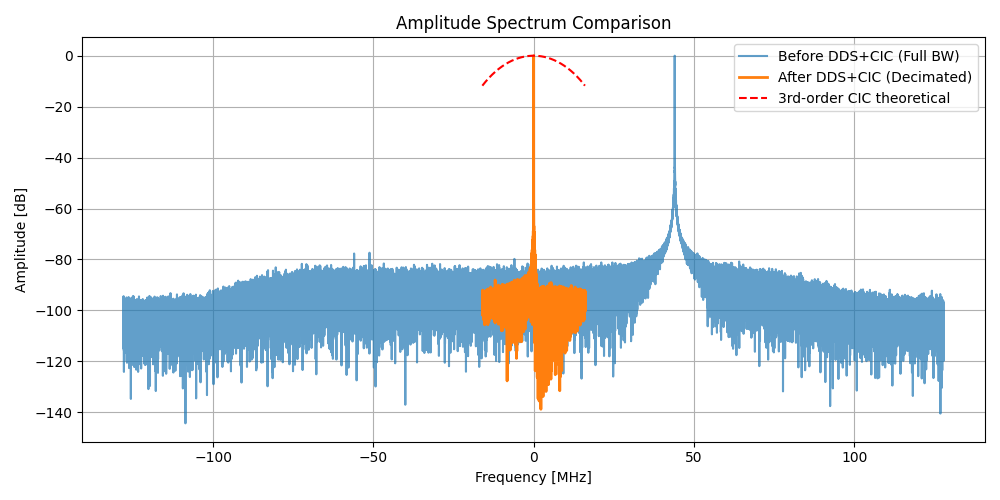

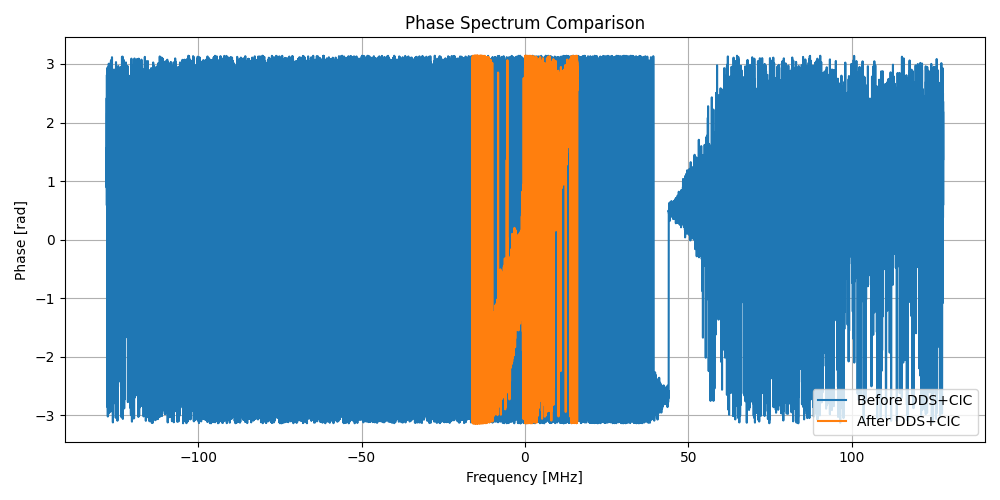

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# ================================
# User parameters
# ================================
data_pre = "data/f_300-10dBm/x_preddscic_t_data.txt"   # signal before DDS+CIC
data_post = "data/f_300-10dBm/x_postddscic_t_data.txt" # signal after DDS+CIC
fs_ch = 256e6       # ADC sampling frequency before decimation
D = 8               # CIC decimation factor
N = 3               # CIC order
# ================================

# Load signals
x_pre = np.loadtxt(data_pre, dtype=complex)
x_post = np.loadtxt(data_post, dtype=complex)

# Effective sampling rate after decimation
fs_d = fs_ch / D
print(f"Effective sampling rate after decimation: {fs_d/1e6:.2f} MHz")

# --- FFT for 'Before' (Full Rate) ---
X_pre = np.fft.fftshift(np.fft.fft(x_pre))
# Use the full ADC sampling rate here
f_axis_pre = np.fft.fftshift(np.fft.fftfreq(len(x_pre), 1/fs_ch))

# --- FFT for 'After' (Decimated Rate) ---
X_post = np.fft.fftshift(np.fft.fft(x_post))
# Use the decimated sampling rate here
f_axis_post = np.fft.fftshift(np.fft.fftfreq(len(x_post), 1/fs_d))

# Normalize amplitudes for comparison
amp_pre_dB = 20*np.log10(np.abs(X_pre)/np.max(np.abs(X_pre)))
amp_post_dB = 20*np.log10(np.abs(X_post)/np.max(np.abs(X_post)))

# Phase
phase_pre_rad = np.angle(X_pre)
phase_post_rad = np.angle(X_post)

# CIC theoretical response
H_cic = np.sinc(f_axis * D / fs_ch)**N
H_cic_dB = 20*np.log10(H_cic/np.max(H_cic))

# -------------------------------
# Plot amplitude comparison
plt.figure(figsize=(10,5))
# Plot 'Before' against the 256MHz-based axis
plt.plot(f_axis_pre/1e6, amp_pre_dB, label='Before DDS+CIC (Full BW)', alpha=0.7)
# Plot 'After' against the 32MHz-based axis
plt.plot(f_axis_post/1e6, amp_post_dB, label='After DDS+CIC (Decimated)', linewidth=2)
#plt.plot(f_axis_pre/1e6, amp_pre_dB, label='Before DDS+CIC')
#plt.plot(f_axis_post/1e6, amp_post_dB, label='After DDS+CIC')
plt.plot(f_axis/1e6, H_cic_dB, 'r--', label='3rd-order CIC theoretical')
plt.xlabel('Frequency [MHz]')
plt.ylabel('Amplitude [dB]')
plt.title('Amplitude Spectrum Comparison')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# -------------------------------
# Plot phase comparison
plt.figure(figsize=(10,5))
plt.plot(f_axis_pre/1e6, phase_pre_rad, label='Before DDS+CIC')
plt.plot(f_axis_post/1e6, phase_post_rad, label='After DDS+CIC')
plt.xlabel('Frequency [MHz]')
plt.ylabel('Phase [rad]')
plt.title('Phase Spectrum Comparison')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

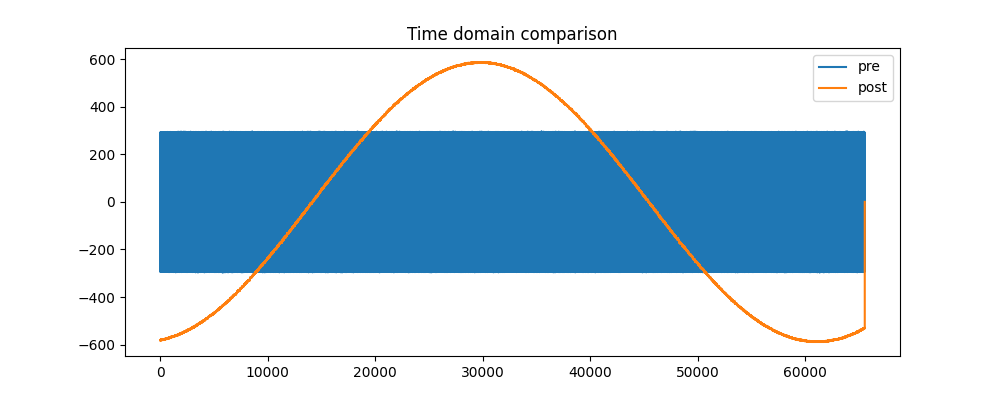

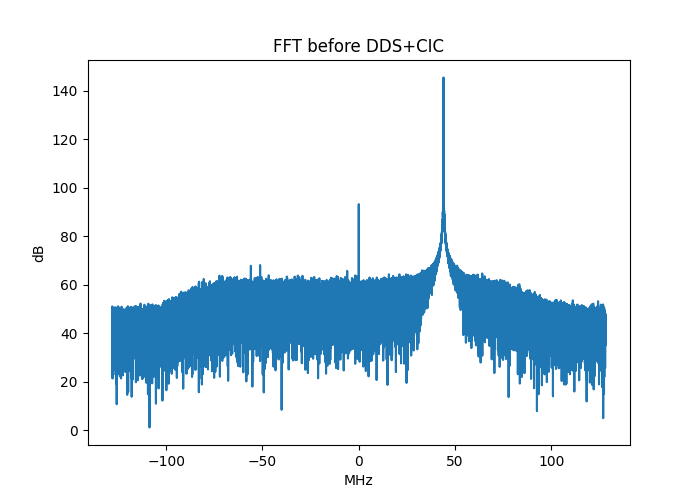

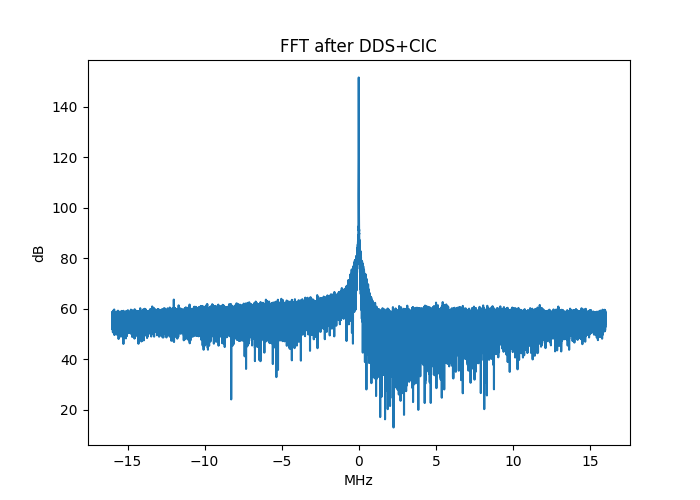

Mean amplitude pre : 293.3585615335397
Mean amplitude post: 586.8301662586881


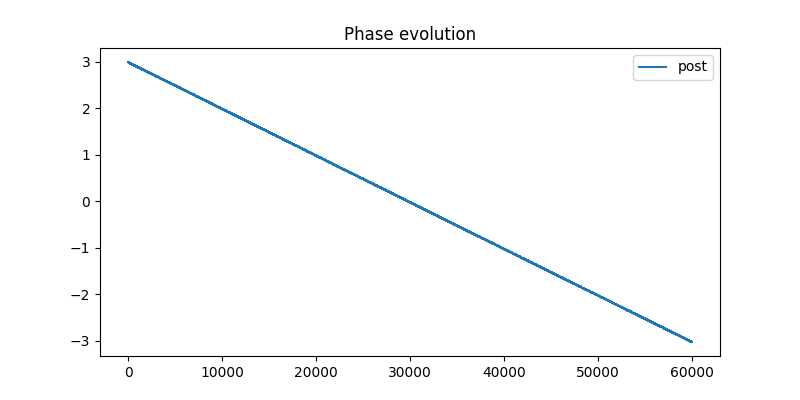

Ganancia del bloque: 2.00
Error de frecuencia residual: -721.02 Hz


In [9]:
import numpy as np
import matplotlib.pyplot as plt

# ===============================
# LOAD DATA
# ===============================

pre  = np.loadtxt("data/f_300-10dBm/x_preddscic_t_data.txt", dtype=np.complex128)
post = np.loadtxt("data/f_300-10dBm/x_postddscic_t_data.txt", dtype=np.complex128)

Fs_pre  = 256e6
Fs_post = 32e6

# if complex IQ stored as I,Q
#if pre.ndim > 1:
#    pre = pre[:,0] + 1j*pre[:,1]

#if post.ndim > 1:
#    post = post[:,0] + 1j*post[:,1]

# ===============================
# TIME DOMAIN
# ===============================

plt.figure(figsize=(10,4))
plt.plot(np.real(pre[:2000000]), label="pre")
plt.plot(np.real(post[:2000000]), label="post")
plt.legend()
plt.title("Time domain comparison")
plt.show()

# ===============================
# FFT PRE
# ===============================

N = len(pre)

fft_pre = np.fft.fftshift(np.fft.fft(pre))
f_pre = np.fft.fftshift(np.fft.fftfreq(N,1/Fs_pre))

plt.figure(figsize=(7,5))
plt.plot(f_pre/1e6,20*np.log10(np.abs(fft_pre)))
plt.title("FFT before DDS+CIC")
plt.xlabel("MHz")
plt.ylabel("dB")
plt.show()

# ===============================
# FFT POST
# ===============================

N = len(post)

fft_post = np.fft.fftshift(np.fft.fft(post))
f_post = np.fft.fftshift(np.fft.fftfreq(N,1/Fs_post))

plt.figure(figsize=(7,5))
plt.plot(f_post/1e6,20*np.log10(np.abs(fft_post)))
plt.title("FFT after DDS+CIC")
plt.xlabel("MHz")
plt.ylabel("dB")
plt.show()

# ===============================
# AMPLITUDE
# ===============================

amp_pre  = np.abs(pre)
amp_post = np.abs(post)

print("Mean amplitude pre :", np.mean(amp_pre))
print("Mean amplitude post:", np.mean(amp_post))

# ===============================
# PHASE
# ===============================

phase_pre  = np.unwrap(np.angle(pre))
phase_post = np.unwrap(np.angle(post))

plt.figure(figsize=(8,4))
#plt.plot(phase_pre[:10000], label="pre")
plt.plot(phase_post[:60000], label="post")
plt.legend()
plt.title("Phase evolution")
plt.show()

gain_factor = np.mean(np.abs(x_post)) / np.mean(np.abs(x_pre))
print(f"Ganancia del bloque: {gain_factor:.2f}")

# Tomamos la diferencia de fase entre el último y el primer punto
delta_phase = phase_post[-1] - phase_post[0]
delta_time = len(phase_post) / fs_d

# Calculamos el error de frecuencia en Hz
f_error = delta_phase / (2 * np.pi * delta_time)
print(f"Error de frecuencia residual: {f_error:.2f} Hz")

## ADC Calibration with PFB and DDS+CIC Chain

### Complete Signal Chain
```
Pin_gen → [Analog Atten] → ADC → PFB → DDS → CIC → Output
```

**Chain breakdown:**
1. **Analog attenuation:** -12.89 dB
2. **ADC:** Converts to digital (characterized by $K_{\text{adc}}$)
3. **PFB:** Divides by $2^{q_{\text{out}}}$ where $q_{\text{out}} = 6$ (i.e., ÷64 = -36.12 dB)
4. **DDS:** Frequency translation (no gain/loss in ideal case)
5. **CIC:** Decimation filter with gain $G_{\text{CIC}} = (RM)^N$

---

## CIC Filter Characteristics

### CIC Gain

For a CIC filter with:
- Decimation factor: $R = 8$
- Differential delay: $M = 1$
- Order: $N = 3$

The CIC gain is:
$$G_{\text{CIC}} = (RM)^N = (8 \times 1)^3 = 512$$

In decibels:
$$G_{\text{CIC,dB}} = 20 \log_{10}(512) = 54.19 \text{ dB}$$

Therefore, the **combined FFT+CIC gain is unity** (0 dB).

---

## Updated Calibration Equation

### Without FFT Pre-compensation

If the FFT does **not** compensate the CIC gain (i.e., `QOUT_REG ≠ 9`):

The complete chain has an additional gain/loss term from FFT and CIC:
$$\text{FFT\_CIC\_NET} = G_{\text{FFT,dB}} + G_{\text{CIC,dB}}$$

Where:
- $G_{\text{FFT,dB}} = -20 \log_{10}(2^{\text{QOUT\_REG}})$
- $G_{\text{CIC,dB}} = 20 \log_{10}(R^N) = 54.19$ dB (for $R=8, N=3$)

The calibration becomes:
$$\boxed{P_{\text{in,gen}} = P_{\text{output,digital}} + \text{CAL\_CONSTANT} - \text{FFT\_CIC\_NET}}$$

### With FFT Pre-compensation (QOUT_REG = 9)

If `QOUT_REG = 9`, then FFT_CIC_NET = 0 dB, and:
$$\boxed{P_{\text{in,gen}} = P_{\text{output,digital}} + \text{CAL\_CONSTANT}}$$

where `CAL_CONSTANT` remains:
$$\text{CAL\_CONSTANT} = \text{PFB\_SCALING} + \text{ANALOG\_ATTEN} - K_{\text{adc}}$$

---

## Effect on Signal Phase

### What QOUT_REG Does NOT Affect

The FFT quantization (`QOUT_REG`) **does not introduce deterministic phase rotation**. The signal phase is preserved.

### What CAN Affect Phase

1. **DDS:** Introduces phase shift $\phi = -2\pi f_{\text{DDS}} t$
   - This is a **linear phase** (frequency translation)
   - Does not change the phase of the tone relative to DC after translation
   
2. **CIC Filter:** Introduces **group delay**
   $$\tau_g = \frac{N(R-1)}{2}$$
   For $N=3, R=8$: $\tau_g = 10.5$ samples
   - This is a **constant delay** (linear phase in frequency)
   - Does not affect relative phase measurements of a single tone

3. **Quantization noise:** Adds small random phase error for low SNR

### Practical Implication

For a single tone:
- **Amplitude** is affected by `QOUT_REG`, CIC gain, etc.
- **Phase** is essentially unchanged (except for predictable linear phase from DDS and CIC delay)
- Phase measurements are **consistent across power levels** if system is linear

---

## Code: Complete Calibration with DDS+CIC

Pin=  -40 dBm → Out= -60.82 dBFS, Phase=  +72.5°, SNR= 27.5 dB, Peak= 0.1%
Pin=  -30 dBm → Out= -53.17 dBFS, Phase= +105.1°, SNR= 35.1 dB, Peak= 0.2%
Pin=  -20 dBm → Out= -43.25 dBFS, Phase=  +98.2°, SNR= 44.0 dB, Peak= 0.6%
Pin=  -15 dBm → Out= -38.33 dBFS, Phase= +173.5°, SNR= 47.2 dB, Peak= 1.0%
Pin=  -10 dBm → Out= -33.18 dBFS, Phase= +162.8°, SNR= 48.8 dB, Peak= 1.8%
Pin=   -5 dBm → Out= -28.20 dBFS, Phase=  -12.8°, SNR= 49.6 dB, Peak= 3.2%
Pin=   -0 dBm → Out= -23.19 dBFS, Phase= +140.1°, SNR= 49.9 dB, Peak= 5.7%
Pin=   +5 dBm → Out= -18.17 dBFS, Phase=  +11.2°, SNR= 50.4 dB, Peak=10.1%
Pin=   +6 dBm → Out= -17.17 dBFS, Phase= +123.2°, SNR= 50.3 dB, Peak=11.3%
Pin=   +7 dBm → Out= -16.26 dBFS, Phase=  +79.8°, SNR= 49.5 dB, Peak=12.6%
Pin=   +8 dBm → Out= -15.77 dBFS, Phase= +177.0°, SNR= 49.3 dB, Peak=13.4%
Pin=  +10 dBm → Out= -15.18 dBFS, Phase=  -44.9°, SNR= 48.8 dB, Peak=14.3%

Linear fit: Pin = 1.037 × P_out + 24.28 dB

DDS+CIC QUANTIZATION AND GAIN ANALYSIS
Configured QPROD

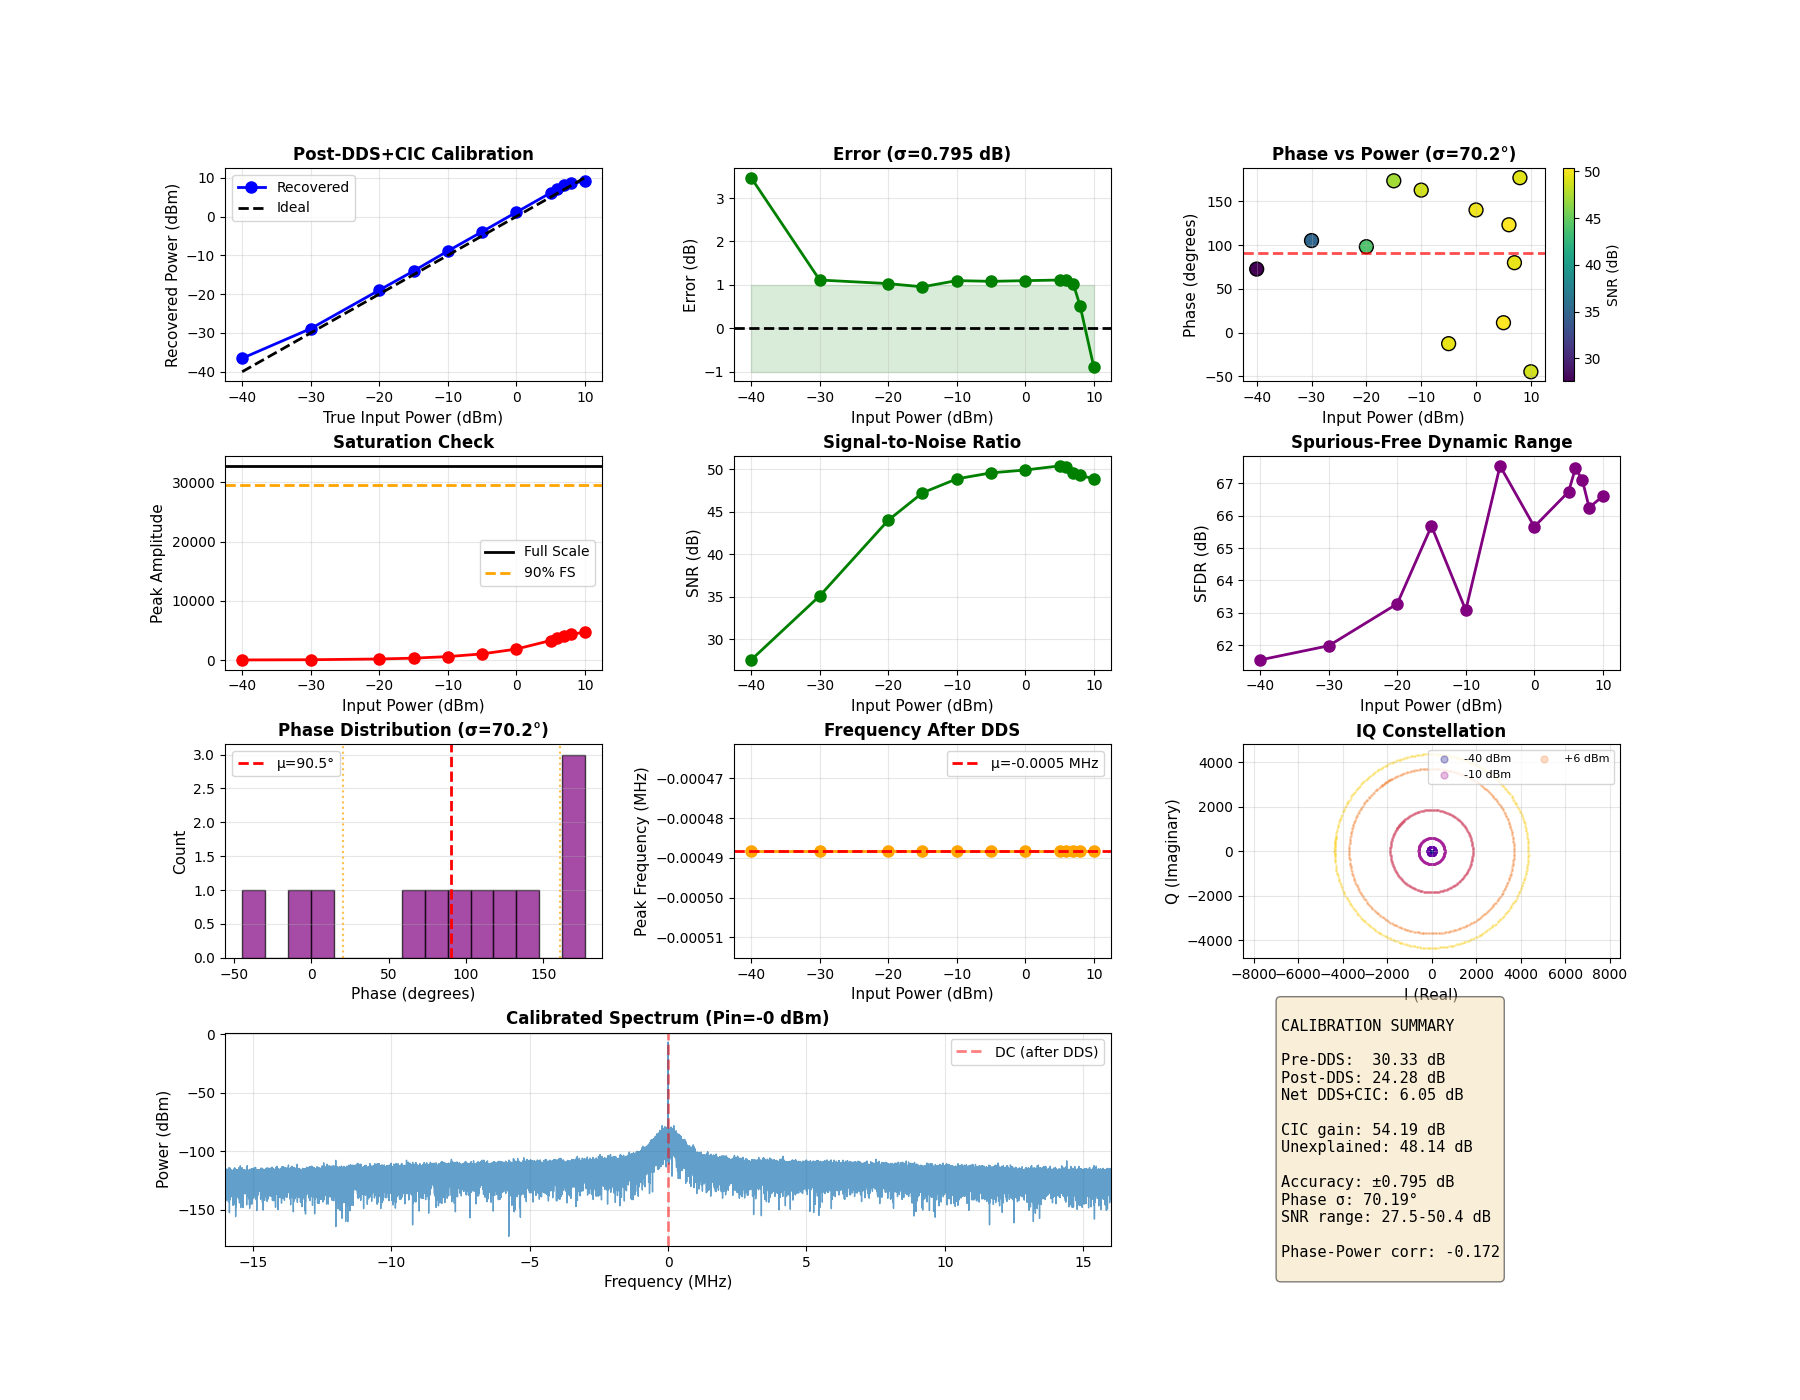


FINAL DIAGNOSTIC REPORT
📊 CALIBRATION:
  • Linear fit accuracy: ±0.795 dB
  • Pin (dBm) ≈ P_out (dBFS) + 24.28

⚙️ DDS+CIC CHAIN (QPROD=14):
  • Theoretical CIC gain: 54.19 dB
  • Truncation effect: 48.16 dB
  • Measured net gain: 6.05 dB
  • Residual unexplained loss: -0.02 dB

📐 PHASE:
  ⚠️ High variation (70.19°) without power correlation


In [23]:
import numpy as np
import matplotlib.pyplot as plt
import glob, re

# ==========================================
# SYSTEM PARAMETERS
# ==========================================
fs_pfb = 256e6      # PFB output rate
fs_adc = 2048e6     # ADC input rate
ANALOG_ATTEN = 12.89  # dB analog attenuation

# PFB
PFB_CHANNELS = 8
PFB_QOUT = 6
PFB_SCALING = 20*np.log10(2**PFB_QOUT)  # dB scaling due to PFB output

# CIC
D = 8   # Decimation
N = 3   # Order
R = D
M = 1
CIC_GAIN = (R*M)**N
CIC_GAIN_DB = 20*np.log10(CIC_GAIN)
fs_out = fs_pfb / D

# DDS+CIC configuration for this measurement
QPROD = 14               # The configured DDS product quantization used in this measurement
QPROD_DDS_INTERNAL = 24  # Internal DDS product width
CIC_OUTPUT_BITS = 16      # Actual output bits

# Pre-DDS calibration
CAL_CONSTANT_PRE = 30.33
K_ADC = PFB_SCALING + ANALOG_ATTEN - CAL_CONSTANT_PRE

# ==========================================
# LOAD DATA
# ==========================================
data_path = "data/f_300*/x_postddscic_t_data.txt"
files = sorted(glob.glob(data_path), key=lambda f: float(re.search(r'(-?\+?\d+)dBm', f).group(1)))

FS = 2**15
tone_bins = 3
measurements = []

# ==========================================
# PROCESS FILES
# ==========================================
for file in files:
    Pin_gen = float(re.search(r'(-?\+?\d+)dBm', file).group(1))
    x = np.loadtxt(file, dtype=np.complex128)
    N_samples = len(x)
    max_val = np.max(np.abs(x))
    std_val = np.std(np.abs(x))
    
    # Window & FFT
    window = np.hanning(N_samples)
    coherent_gain = np.sum(window)/N_samples
    xw = x*window
    fft_complex = np.fft.fftshift(np.fft.fft(xw)/N_samples)
    freqs = np.fft.fftshift(np.fft.fftfreq(N_samples, 1/fs_out))
    mag = np.abs(fft_complex)/coherent_gain
    
    # Peak detection & tone power
    peak_idx = np.argmax(mag)
    f_peak = freqs[peak_idx]
    idx0, idx1 = peak_idx - tone_bins, peak_idx + tone_bins + 1
    tone_power = np.sum(mag[idx0:idx1]**2)
    P_output_dbfs = 10*np.log10(tone_power/(FS**2))
    
    # Phase
    tone_phase = np.angle(fft_complex[peak_idx])
    
    # SNR & SFDR
    noise_mask = np.ones(len(mag), dtype=bool)
    noise_mask[idx0:idx1] = False
    noise_power = np.mean(mag[noise_mask]**2)
    snr_db = 10*np.log10(tone_power/(len(mag)*noise_power))
    mag_no_tone = mag.copy(); mag_no_tone[idx0:idx1] = 0
    sfdr_db = 10*np.log10(tone_power/np.max(mag_no_tone)**2)
    
    measurements.append({
        'Pin_gen': Pin_gen,
        'P_output_dbfs': P_output_dbfs,
        'f_peak': f_peak,
        'phase': tone_phase,
        'max_val': max_val,
        'std_val': std_val,
        'snr_db': snr_db,
        'sfdr_db': sfdr_db,
        'file': file
    })
    
    saturation_pct = (max_val/FS)*100
    sat_flag = " ⚠️ SAT" if saturation_pct > 90 else ""
    print(f"Pin={Pin_gen:+5.0f} dBm → Out={P_output_dbfs:7.2f} dBFS, Phase={np.degrees(tone_phase):+7.1f}°, SNR={snr_db:5.1f} dB, Peak={saturation_pct:4.1f}%{sat_flag}")

# ==========================================
# CALIBRATION
# ==========================================
linear_meas = measurements[:8]
Pin_vals = np.array([m['Pin_gen'] for m in linear_meas])
Pout_vals = np.array([m['P_output_dbfs'] for m in linear_meas])
coeffs = np.polyfit(Pout_vals, Pin_vals, 1)
slope = coeffs[0]
CAL_CONSTANT_POST = coeffs[1]

print(f"\nLinear fit: Pin = {slope:.3f} × P_out + {CAL_CONSTANT_POST:.2f} dB")

# ==========================================
# DDS+CIC QUANTIZATION AND GAIN ANALYSIS
# ==========================================
print(f"\n{'='*80}")
print("DDS+CIC QUANTIZATION AND GAIN ANALYSIS")
print(f"{'='*80}")

TRUNC_BITS = QPROD_DDS_INTERNAL - CIC_OUTPUT_BITS
TRUNC_DB = 6.02*TRUNC_BITS
DDS_CIC_NET_EFFECT = CAL_CONSTANT_PRE - CAL_CONSTANT_POST
UNACCOUNTED_LOSS = CIC_GAIN_DB - DDS_CIC_NET_EFFECT
residual_loss = UNACCOUNTED_LOSS - TRUNC_DB

print(f"Configured QPROD = {QPROD} (used for this data)")
print(f"Internal DDS width: {QPROD_DDS_INTERNAL} bits, CIC output: {CIC_OUTPUT_BITS} bits")
print(f"Truncation effect: {TRUNC_BITS} bits → {TRUNC_DB:.2f} dB")
print(f"Theoretical CIC gain: {CIC_GAIN_DB:.2f} dB")
print(f"Measured net gain: {DDS_CIC_NET_EFFECT:.2f} dB")
print(f"Residual unexplained loss: {residual_loss:.2f} dB (likely internal scaling/truncation effects)")

# ==========================================
# PHASE ANALYSIS
# ==========================================
Pin_list = [m['Pin_gen'] for m in measurements]
phases_deg = [np.degrees(m['phase']) for m in measurements]
phase_mean = np.mean(phases_deg)
phase_std = np.std(phases_deg)
phase_power_corr = np.corrcoef(Pin_list, phases_deg)[0,1]

print(f"\nPhase mean: {phase_mean:.2f}°, std dev: {phase_std:.2f}°")
print(f"Phase-Power correlation: {phase_power_corr:.3f}")

# ==========================================
# PLOTTING
# ==========================================
fig = plt.figure(figsize=(18, 14))
gs = fig.add_gridspec(4, 3, hspace=0.35, wspace=0.35)

# Calibration
ax1 = fig.add_subplot(gs[0, 0])
Pin_recovered = [m['P_output_dbfs'] + CAL_CONSTANT_POST for m in measurements]
errors = np.array(Pin_recovered) - np.array(Pin_list)
ax1.plot(Pin_list, Pin_recovered, 'o-', ms=8, lw=2, color='blue', label='Recovered')
ax1.plot(Pin_list, Pin_list, 'k--', lw=2, label='Ideal')
ax1.set_xlabel('True Input Power (dBm)', fontsize=11)
ax1.set_ylabel('Recovered Power (dBm)', fontsize=11)
ax1.set_title('Post-DDS+CIC Calibration', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Calibration Error
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(Pin_list, errors, 'o-', ms=8, lw=2, color='green')
ax2.axhline(0, color='k', ls='--', lw=2)
ax2.fill_between(Pin_list, -1, 1, alpha=0.15, color='green')
ax2.set_xlabel('Input Power (dBm)', fontsize=11)
ax2.set_ylabel('Error (dB)', fontsize=11)
ax2.set_title(f'Error (σ={np.std(errors[:8]):.3f} dB)', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)

# Phase vs Power (KEY DIAGNOSTIC)
ax3 = fig.add_subplot(gs[0, 2])
snr_list = [m['snr_db'] for m in measurements]
scatter = ax3.scatter(Pin_list, phases_deg, c=snr_list, s=100, 
                     cmap='viridis', edgecolors='k', linewidth=1)
ax3.axhline(phase_mean, color='r', ls='--', lw=2, alpha=0.7)
if abs(phase_power_corr) > 0.5:
    p_fit = np.poly1d(coeffs_phase)
    ax3.plot(Pin_list, p_fit(Pin_list), 'r-', lw=2, alpha=0.5,
             label=f'r={phase_power_corr:.2f}')
    ax3.legend()
ax3.set_xlabel('Input Power (dBm)', fontsize=11)
ax3.set_ylabel('Phase (degrees)', fontsize=11)
ax3.set_title(f'Phase vs Power (σ={phase_std:.1f}°)', fontsize=12, fontweight='bold')
plt.colorbar(scatter, ax=ax3, label='SNR (dB)')
ax3.grid(True, alpha=0.3)

# Saturation Check
ax4 = fig.add_subplot(gs[1, 0])
max_vals = [m['max_val'] for m in measurements]
ax4.plot(Pin_list, max_vals, 'o-', ms=8, lw=2, color='red')
ax4.axhline(FS, color='k', ls='-', lw=2, label='Full Scale')
ax4.axhline(0.9*FS, color='orange', ls='--', lw=2, label='90% FS')
ax4.set_xlabel('Input Power (dBm)', fontsize=11)
ax4.set_ylabel('Peak Amplitude', fontsize=11)
ax4.set_title('Saturation Check', fontsize=12, fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3)

# SNR
ax5 = fig.add_subplot(gs[1, 1])
ax5.plot(Pin_list, snr_list, 'o-', ms=8, lw=2, color='green')
ax5.set_xlabel('Input Power (dBm)', fontsize=11)
ax5.set_ylabel('SNR (dB)', fontsize=11)
ax5.set_title('Signal-to-Noise Ratio', fontsize=12, fontweight='bold')
ax5.grid(True, alpha=0.3)

# SFDR
ax6 = fig.add_subplot(gs[1, 2])
sfdr_list = [m['sfdr_db'] for m in measurements]
ax6.plot(Pin_list, sfdr_list, 'o-', ms=8, lw=2, color='purple')
ax6.set_xlabel('Input Power (dBm)', fontsize=11)
ax6.set_ylabel('SFDR (dB)', fontsize=11)
ax6.set_title('Spurious-Free Dynamic Range', fontsize=12, fontweight='bold')
ax6.grid(True, alpha=0.3)

# Phase Histogram
ax7 = fig.add_subplot(gs[2, 0])
ax7.hist(phases_deg, bins=15, edgecolor='k', alpha=0.7, color='purple')
ax7.axvline(phase_mean, color='r', ls='--', lw=2, label=f'μ={phase_mean:.1f}°')
ax7.axvline(phase_mean - phase_std, color='orange', ls=':', lw=1.5, alpha=0.7)
ax7.axvline(phase_mean + phase_std, color='orange', ls=':', lw=1.5, alpha=0.7)
ax7.set_xlabel('Phase (degrees)', fontsize=11)
ax7.set_ylabel('Count', fontsize=11)
ax7.set_title(f'Phase Distribution (σ={phase_std:.1f}°)', fontsize=12, fontweight='bold')
ax7.legend()
ax7.grid(True, alpha=0.3, axis='y')

# Frequency Stability
ax8 = fig.add_subplot(gs[2, 1])
freqs_peak = [m['f_peak']/1e6 for m in measurements]
ax8.plot(Pin_list, freqs_peak, 'o-', ms=8, lw=2, color='orange')
ax8.axhline(np.mean(freqs_peak), color='r', ls='--', lw=2, 
            label=f'μ={np.mean(freqs_peak):.4f} MHz')
ax8.set_xlabel('Input Power (dBm)', fontsize=11)
ax8.set_ylabel('Peak Frequency (MHz)', fontsize=11)
ax8.set_title('Frequency After DDS', fontsize=12, fontweight='bold')
ax8.legend()
ax8.grid(True, alpha=0.3)

# IQ Constellation
ax9 = fig.add_subplot(gs[2, 2])
colors = plt.cm.plasma(np.linspace(0, 1, len(measurements)))
for i, (m, c) in enumerate(zip(measurements[::2], colors[::2])):  # Plot every other
    x_data = np.loadtxt(m['file'], dtype=np.complex128)
    subsample = max(1, len(x_data) // 400)
    label = f"{m['Pin_gen']:+.0f} dBm" if i % 2 == 0 else ""
    ax9.scatter(np.real(x_data[::subsample]), np.imag(x_data[::subsample]),
               alpha=0.3, s=1, color=c, label=label)
ax9.set_xlabel('I (Real)', fontsize=11)
ax9.set_ylabel('Q (Imaginary)', fontsize=11)
ax9.set_title('IQ Constellation', fontsize=12, fontweight='bold')
ax9.legend(fontsize=8, markerscale=5, ncol=2)
ax9.grid(True, alpha=0.3)
ax9.axis('equal')

# Spectrum (middle power)
ax10 = fig.add_subplot(gs[3, :2])
mid_idx = len(measurements) // 2
x_mid = np.loadtxt(measurements[mid_idx]['file'], dtype=np.complex128)
window_mid = np.hanning(len(x_mid))
X_mid = np.fft.fftshift(np.fft.fft(x_mid * window_mid) / len(x_mid))
f_mid = np.fft.fftshift(np.fft.fftfreq(len(x_mid), 1/fs_out))
mag_mid_dbm = 20*np.log10(np.abs(X_mid)/FS) + CAL_CONSTANT_POST
ax10.plot(f_mid/1e6, mag_mid_dbm, lw=1, alpha=0.7)
ax10.axvline(0, color='r', ls='--', lw=2, alpha=0.5, label='DC (after DDS)')
ax10.set_xlabel('Frequency (MHz)', fontsize=11)
ax10.set_ylabel('Power (dBm)', fontsize=11)
ax10.set_title(f'Calibrated Spectrum (Pin={Pin_list[mid_idx]:+.0f} dBm)', 
              fontsize=12, fontweight='bold')
ax10.legend()
ax10.grid(True, alpha=0.3)
ax10.set_xlim([-fs_out/2/1e6, fs_out/2/1e6])

# Summary Table
ax11 = fig.add_subplot(gs[3, 2])
ax11.axis('off')
summary_text = f"""
CALIBRATION SUMMARY

Pre-DDS:  {CAL_CONSTANT_PRE:.2f} dB
Post-DDS: {CAL_CONSTANT_POST:.2f} dB
Net DDS+CIC: {DDS_CIC_NET_EFFECT:.2f} dB

CIC gain: {CIC_GAIN_DB:.2f} dB
Unexplained: {UNACCOUNTED_LOSS:.2f} dB

Accuracy: ±{np.std(errors[:8]):.3f} dB
Phase σ: {phase_std:.2f}°
SNR range: {np.min(snr_list):.1f}-{np.max(snr_list):.1f} dB

Phase-Power corr: {phase_power_corr:.3f}
"""
ax11.text(0.1, 0.5, summary_text, transform=ax11.transAxes,
         fontsize=11, verticalalignment='center', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.savefig('ddscic_complete_analysis.pdf', dpi=300, bbox_inches='tight')
plt.show()

# ==========================================
# FINAL REPORT
# ==========================================
print(f"\n{'='*80}")
print("FINAL DIAGNOSTIC REPORT")
print(f"{'='*80}")

print(f"📊 CALIBRATION:")
print(f"  • Linear fit accuracy: ±{np.std(Pout_vals - Pin_vals):.3f} dB")
print(f"  • Pin (dBm) ≈ P_out (dBFS) + {CAL_CONSTANT_POST:.2f}")

print(f"\n⚙️ DDS+CIC CHAIN (QPROD={QPROD}):")
print(f"  • Theoretical CIC gain: {CIC_GAIN_DB:.2f} dB")
print(f"  • Truncation effect: {TRUNC_DB:.2f} dB")
print(f"  • Measured net gain: {DDS_CIC_NET_EFFECT:.2f} dB")
print(f"  • Residual unexplained loss: {residual_loss:.2f} dB")

print(f"\n📐 PHASE:")
if phase_std < 10:
    print(f"  ✅ Excellent: {phase_std:.2f}° std dev")
elif phase_std < 20:
    print(f"  ✓ Good: {phase_std:.2f}° std dev")
elif abs(phase_power_corr) > 0.7:
    print(f"  ⚠️ Phase depends on power (r={phase_power_corr:.2f})")
else:
    print(f"  ⚠️ High variation ({phase_std:.2f}°) without power correlation")